# Deep Learning
## Actividad 1: Deep Vision

Joaquin Perticari

Jordi Servat

Christian Méndez


# Actividad Deep Vision

Diseñar y comparar dos estrategias para la clasificación de imágenes en el dataset CIFAR100 de Keras (https://keras.io/api/datasets/cifar100/)

### **Estrategia 1: Red pre-entrenada**

La primera estrategia a comparar debe incluir la utilización de redes preentrenadas con el dataset ImageNet, llevando a cabo tareas de *transfer learning* y *fine-tuning* para clasificar los objetos de CIFAR100. Deben compararse al menos dos tipos de arquitecturas (VGGs, ResNet50, Xception, InceptionV3, InceptionResNetV2, MobileNetV2, DenseNet, ResNet...) y se debe seleccionar la que mayor precisión nos dé (información sobre las arquitecturas disponibles en https://keras.io/applications/). Se espera que el ejercicio presente una profunda experimentación haciendo uso todas las técnicas de optimización mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (weight regularization, dropout, batch normalization, data augmentation, etc.).

### **Estrategia 2: Entrenar desde cero o from scratch**

La segunda estrategia a comparar será una red neuronal que se debe diseñar, entrenar y optimizar. Se requiere una justificación empírica de las decisiones que llevaron a la selección de atributos, capas e hiperparámetros a los que se ha llegado. Se espera que el ejercicio presente una profunda experimentación haciendo uso de todas las técnicas de optimización mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (weight regularization, dropout, batch normalization, data augmentation...).

## Normas a seguir

- Se debe entregar un **ÚNICO GOOGLE COLAB notebook** (archivo .ipynb) que incluya las instrucciones presentes y su **EJECUCIÓN!!!**. Debe aparecer todo el proceso seguido (carga de datos, visualización de datos, proceso de entrenamiento y proceso de validación del modelo).
- Poner el nombre del grupo en el nombre del archivo y el nombre de todos los integrantes del grupo al inicio del notebook.
- Las redes utilizadas deben estar entrenadas y con las métricas extraídas en el conjunto de test.
- Es recomendable crear una última sección de texto en el notebook en la que se discutan los diferentes modelos obtenidos y se extraigan las conclusiones pertinentes.

## Criterio de evaluación

- Seguimiento de las normas establecidas en la actividad.
- Efectividad al presentar las comparaciones entre métricas de evaluación de ambos modelos.
- Demostración de la utilización de técnicas de optimización para mejorar el rendimiento de los modelos.
- Modelos predictivos con rendimiento superior al aleatorio.
- Corrección en el uso de algoritmos, modelos y formas idiomáticas en Python.
- El código debe poder ejecutarse sin modificación alguna en Google Colaboratory.

Recomendaciones en el Uso de Colab:

- Eliminar las variables innecesarias para liberar RAM mediante la sentencia:

# PREPARACIÓN

**IMPORTACIÓN DE LIBRERÍAS**

In [ ]:
!pip install tensorflow
!pip install scikit-learn

In [ ]:
# Import the necessary packages
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tarfile
import pickle
import random
%matplotlib inline

from tensorflow.keras import backend as K
from tensorflow.keras.layers import Input, Conv2D, Activation, Flatten, Dense, Dropout, BatchNormalization, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras import regularizers
from sklearn.metrics import classification_report
# from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

# Cargamos el dataset de cifar100
from tensorflow.keras.datasets import cifar100

**Cargando los datos**

In [ ]:
# Carga de datos
print("[INFO]: Loading CIFAR-100 data...")
((x_train, y_train), (x_test, y_test)) = cifar100.load_data(label_mode='fine')

# CIFAR100 labelnames
labelNames = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']

[INFO]: Loading CIFAR-100 data...


**Definición de las funciones de entrenamiento**

In [ ]:
# Función de entrenamiento sin aplicar data augmentation
def train(x_train, y_train, x_test, y_test, pre_trained_model, BASE_FOLDER, learn_rate=0.0005):
  # Resumen del modelo
  pre_trained_model.summary()

  # Compilar el modelo
  print("[INFO]: Compilando el modelo...")
  pre_trained_model.compile(loss="categorical_crossentropy", optimizer=Adam(learning_rate=learn_rate), metrics=["accuracy"])

  # Entrenamiento de la red
  print("[INFO]: Entrenando la red...")
  H_pre = pre_trained_model.fit(x_train, y_train, batch_size=128, epochs=20, validation_split=0.2) # Destinamos 20% a validación
  # Almaceno el modelo en Drive
  # Almacenamos el modelo empleando la función mdoel.save de Keras
  pre_trained_model.save(BASE_FOLDER+"deepCNN_CALTECH101_pretrained.h5")

  # Evaluación del modelo
  print("[INFO]: Evaluando el modelo...")
  # Efectuamos la predicción (empleamos el mismo valor de batch_size que en training)
  predictions = pre_trained_model.predict(x_test, batch_size=128)
  # Sacamos el report para test
  print(classification_report(y_test.argmax(axis=1), predictions.argmax(axis=1), target_names=labelNames))

  # Gráficas
  plt.style.use("ggplot")
  plt.figure()
  plt.plot(np.arange(0, 20), H_pre.history["loss"], label="train_loss")
  plt.plot(np.arange(0, 20), H_pre.history["val_loss"], label="val_loss")
  plt.plot(np.arange(0, 20), H_pre.history["accuracy"], label="train_acc")
  plt.plot(np.arange(0, 20), H_pre.history["val_accuracy"], label="val_acc")
  plt.title("Training Loss and Accuracy")
  plt.xlabel("Epoch #")
  plt.ylabel("Loss/Accuracy")
  plt.legend()
  plt.show()

**Inspeccionando los datos**

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)
Número de clases: 100


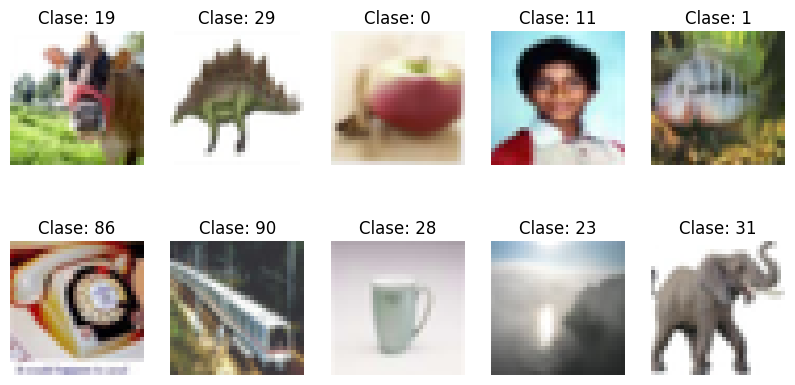

La clase es [31]


In [ ]:
# Ver las dimensiones de los datos
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")


# Número de clases
num_classes = len(np.unique(y_train))
print(f"Número de clases: {num_classes}")

# Mostrar algunas imágenes de ejemplo (opcional)
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(f"Clase: {y_train[i][0]}")
    plt.axis('off')
plt.show()
print("La clase es %s" %(y_train[i]))

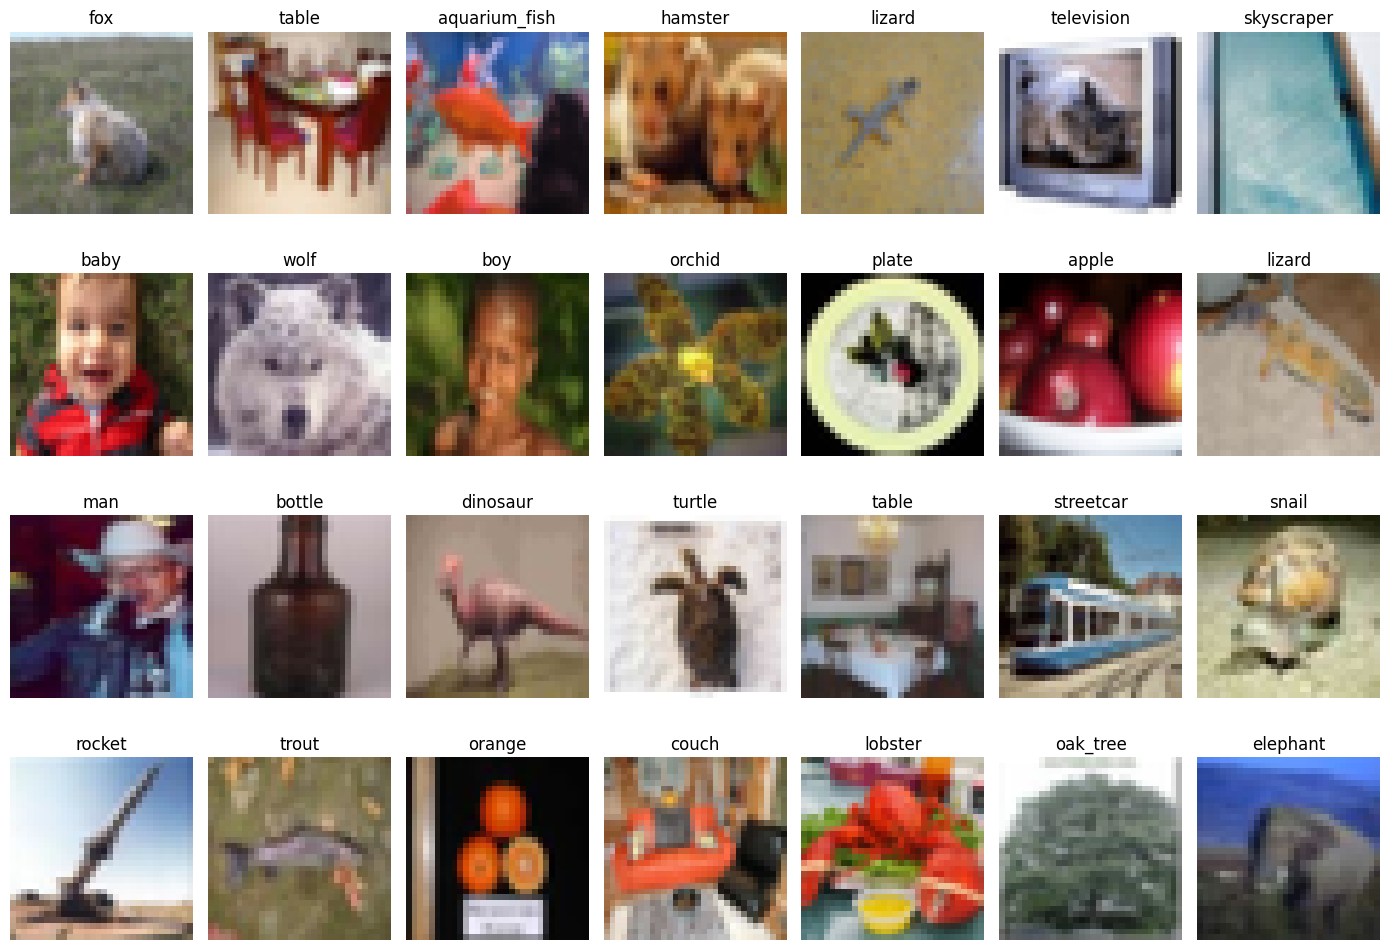

In [ ]:
fig = plt.figure(figsize=(14, 10))

# Seleccionar 28 índices aleatorios del conjunto de entrenamiento
indices = random.sample(range(len(x_train)), 28)

for n, i in enumerate(indices):
    fig.add_subplot(4, 7, n + 1)
    img = x_train[i]                # la imagen
    label_idx = y_train[i][0]        # índice de la clase (si y_train tiene forma (N,1))
    class_name = labelNames[label_idx]  # nombre de la clase
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

[Text(0.5, 1.0, 'Número de muestras por clase'),
 Text(0, 0.5, 'Número de muestras')]

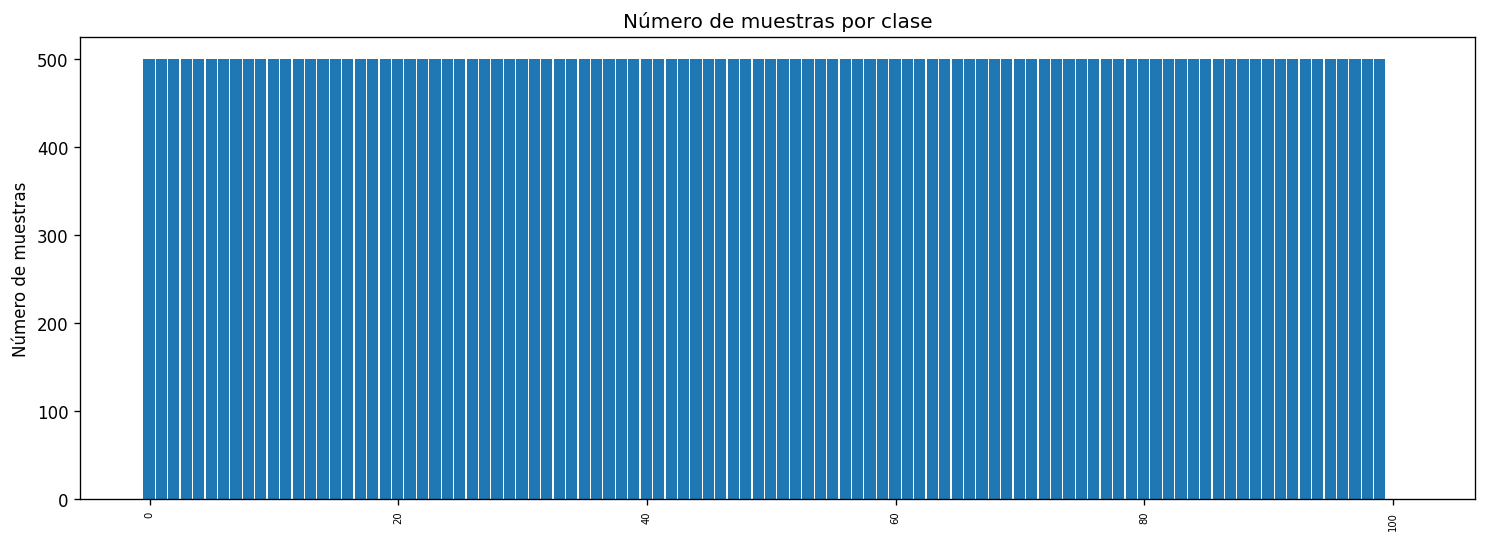

In [ ]:
plt.rcParams.update({'figure.figsize':(15,5), 'figure.dpi':120})

# Plot Histogram on x
plt.hist(y_train, bins=range(0,103), width=0.9, align='left')
plt.xticks(rotation = 90, size=6)
plt.gca().set(title='Número de muestras por clase', ylabel='Número de muestras')

In [ ]:
print(y_train.max())

99


Para obtener la solución final, se siguen los siguientes pasos:

  1. En primer lugar, se obtienen los resultados tras aplicar TRANSFER LEARNING con la red MobileNetV2
  2. Se aplicará FINE TUNING
  3. Se valorará modificar la estructura del TOP MODEL (capas convolucionales y número de neuronas)
  4. Se valorarán distintas técnicas de regularización (weight regularization, dropout y batch normalization)
  5. Se aplicará DATA AUGMENTATION


In [ ]:
# Preparación OHE
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train, 100)
y_test_cat = to_categorical(y_test, 100)

# PRUEBA CON MOBILENETV2

In [ ]:
labelNames = np.unique(y_train)
print("Las %d clases son: " %(len(labelNames)))
print(labelNames)

Las 100 clases son: 
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]


En primer lugar, utilizaremos la red MobileNetV2

**Acondicionando el conjunto de datos para la red MobileNetV2**

In [ ]:
# ============================================
# 1. Verificar rango de píxeles y preprocesar
# ============================================
print("Rango original:", x_train.min(), x_train.max())
print("Rango original:", x_test.min(), x_test.max())

# Si están en [0,255], no multipliques. Si están en [0,1], descomenta la línea:
# x_train, x_test = x_train * 255.0, x_test * 255.0

# from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
# x_train = preprocess_input(x_train.astype('float32'))
# x_test = preprocess_input(x_test.astype('float32'))

Rango original: 0 255
Rango original: 0 255


In [ ]:
# ============================================
# 2. Convertir etiquetas a one-hot
# ============================================
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train, 100)
y_test_cat = to_categorical(y_test, 100)

#### **Cargando la topología de CNN (base model)**

In [ ]:
# ============================================
# 3. Definir modelo base (MobileNetV2)
# ============================================
from tensorflow.keras.applications import MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32,32,3))
base_model.trainable = False

base_model.summary()

/tmp/ipykernel_28774/2588558290.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32,32,3))


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 16, 16,    │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 16, 16,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 16, 16,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 16, 16,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 16, 16,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 16, 16,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 17, 17,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 8, 8, 96)  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │          0 │ block_1_depthwis… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 8, 8, 24)  │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ============================================
# 4. Normalizamos los datos
# ============================================

from tensorflow.keras.applications.mobilenet import preprocess_input

# Los datos están normalizados y preprocess_input requiere un rango [0, 255]
# Multiplicamos *255
# x_train, x_test = x_train * 255.0, x_test * 255.0

# Se normalizan los datos como se normalizaron en el entrenamiento de ImageNet con la red MobileNetV2
x_train_m = preprocess_input(x_train)
x_test_m = preprocess_input(x_test)

# Keras tiene una función para pasar directamente los datos en [0,1] o en [0,255]

#### **Creando el top model y congelando TODAS las capas convolucionales (TRANSFER LEARNING) + Entrenamiento**

In [ ]:
# ============================================
# 5. Construir modelo completo
# ============================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

pre_trained_model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dense(100, activation='softmax')  # 100 clases
])
pre_trained_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,965,156 (11.31 MB)

 Trainable params: 707,172 (2.70 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,965,156 (11.31 MB)

 Trainable params: 707,172 (2.70 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 85ms/step - accuracy: 0.0527 - loss: 4.4319 - val_accuracy: 0.0707 - val_loss: 4.2846
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.0890 - loss: 4.1534 - val_accuracy: 0.0851 - val_loss: 4.1534
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1021 - loss: 4.0363 - val_accuracy: 0.0878 - val_loss: 4.1018
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1108 - loss: 3.9679 - val_accuracy: 0.0914 - val_loss: 4.0795
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1170 - loss: 3.9192 - val_accuracy: 0.0964 - val_loss: 4.0574
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1218 - loss: 3.8792 - val_accuracy: 0.0960 - val_loss: 4.0452
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1294 - loss: 3.8443 - val_accuracy: 0.0962 - val_loss: 4.0402
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step
               precision    recall  f1-score   support

        apple       0.35      0.56      0.43       100
aquarium_fish       0.04      0.04      0.04       100
         baby       0.08      0.02      0.03       100
         bear       0.10      0.02      0.03       100
       beaver       0.00      0.00      0.00       100
          bed       0.12      0.04      0.06       100
          bee       0.15      0.08      0.11       100
       beetle       0.14      0.03      0.05       100
      bicycle       0.25      0.40      0.31       100
       bottle       0.09      0.15      0.11       100
         bowl       0.05      0.10      0.06       100
          boy       0.01      0.01      0.01       100
       bridge       0.13      0.08      0.10       100
          bus       0.07      0.04      0.05       100
    butterfly       0.06      0.06      0.06       100
        camel       0.18      0.02      0.04    

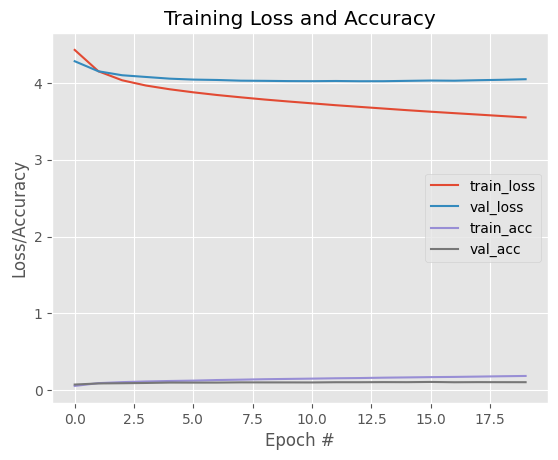

In [ ]:
# ============================================
# 6. Crear carpeta de resultados y entrenar
# ============================================
import os
BASE_FOLDER = './resultados/'
os.makedirs(BASE_FOLDER, exist_ok=True)

# Llamar a train con las etiquetas one-hot
train(x_train_m, y_train_cat, x_test_m, y_test_cat, pre_trained_model, BASE_FOLDER)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,965,156 (11.31 MB)

 Trainable params: 707,172 (2.70 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

...

 Total params: 2,965,156 (11.31 MB)

 Trainable params: 707,172 (2.70 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.0518 - loss: 4.4355 - val_accuracy: 0.0721 - val_loss: 4.2889
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0851 - loss: 4.1582 - val_accuracy: 0.0828 - val_loss: 4.1570
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1016 - loss: 4.0394 - val_accuracy: 0.0889 - val_loss: 4.1138
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.1104 - loss: 3.9722 - val_accuracy: 0.0940 - val_loss: 4.0758
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1177 - loss: 3.9224 - val_accuracy: 0.0930 - val_loss: 4.0634
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1218 - loss: 3.8827 - val_accuracy: 0.0972 - val_loss: 4.0484
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1294 - loss: 3.8482 - val_accuracy: 0.0980 - val_loss: 4.0418
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step
               precision    recall  f1-score   support

        apple       0.36      0.52      0.42       100
aquarium_fish       0.08      0.04      0.05       100
         baby       0.12      0.02      0.03       100
         bear       0.15      0.03      0.05       100
       beaver       0.08      0.01      0.02       100
          bed       0.12      0.05      0.07       100
          bee       0.18      0.10      0.13       100
       beetle       0.33      0.02      0.04       100
      bicycle       0.32      0.35      0.34       100
       bottle       0.13      0.10      0.11       100
         bowl       0.03      0.01      0.01       100
          boy       0.02      0.01      0.01       100
       bridge       0.14      0.13      0.14       100
          bus       0.04      0.02      0.03       100
    butterfly       0.04      0.03      0.03       100
        camel       0.10      0.04      0.06    

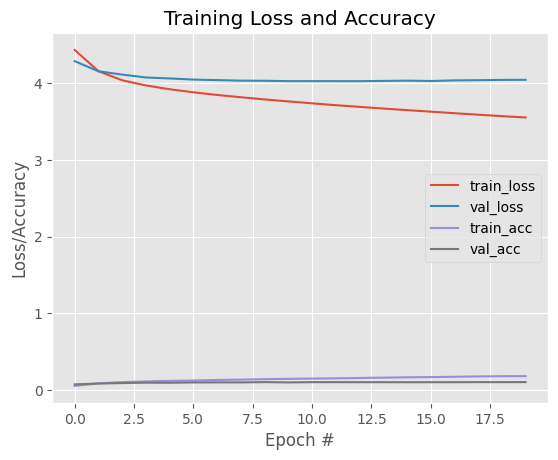

In [ ]:
# conectarlo a nueva parte densa
base_model.trainable = False # Evitar que los pesos se modifiquen en la parte convolucional -> TRANSFER LEARNING
pre_trained_model = Sequential()
pre_trained_model.add(base_model)
pre_trained_model.add(layers.Flatten())
pre_trained_model.add(layers.Dense(512, activation='relu'))
pre_trained_model.add(layers.Dense(100, activation='softmax'))
pre_trained_model.summary()

# Entrenando la solución
train(x_train_m, y_train_cat, x_test_m, y_test_cat, pre_trained_model, BASE_FOLDER)

# EJERCICIO 1

## Análisis general

### **Miramos la compatibilidad de todos los modelos**

In [ ]:
from tensorflow.keras import layers, Sequential

from tensorflow.keras.applications import Xception, VGG16,VGG19,ResNet50,ResNet50V2,ResNet101,ResNet152,ResNet152V2,InceptionV3,InceptionResNetV2,MobileNet,MobileNetV2,DenseNet121,DenseNet169,DenseNet201,EfficientNetB0,EfficientNetB1,EfficientNetB2,EfficientNetB3,EfficientNetB4,EfficientNetB5,EfficientNetB6,EfficientNetB7,EfficientNetV2B0,EfficientNetV2B1,EfficientNetV2B2,EfficientNetV2B3,EfficientNetV2S,EfficientNetV2M,EfficientNetV2L,ConvNeXtTiny,ConvNeXtSmall,ConvNeXtBase,ConvNeXtLarge,ConvNeXtXLarge


All_models=[Xception,VGG16,VGG19,ResNet50,ResNet50V2,ResNet101,ResNet152,ResNet152V2,InceptionV3,InceptionResNetV2,MobileNet,MobileNetV2,DenseNet121,DenseNet169,DenseNet201,EfficientNetB0,EfficientNetB1,EfficientNetB2,EfficientNetB3,EfficientNetB4,EfficientNetB5,EfficientNetB6,EfficientNetB7,EfficientNetV2B0,EfficientNetV2B1,EfficientNetV2B2,EfficientNetV2B3,EfficientNetV2S,EfficientNetV2M,EfficientNetV2L,ConvNeXtTiny,ConvNeXtSmall,ConvNeXtBase,ConvNeXtLarge,ConvNeXtXLarge]

for model in All_models:
    # FASE 1: Probar únicamente si el modelo acepta 32x32
    try:
        base_model = model(weights='imagenet',
                           include_top=False,
                           input_shape=(32,32,3))
    except ValueError as e:
        # Si falla aquí, efectivamente el modelo o la versión de Keras rechaza el input
        print(f"❌ El modelo {model.__name__} NO admite 32x32. Razón: {e}")
        continue # Pasamos al siguiente modelo sin ejecutar el resto

    # FASE 2: Construir y entrenar
    try:
        base_model.trainable = False
        pre_trained_model = Sequential()
        pre_trained_model.add(base_model)
        pre_trained_model.add(layers.Flatten())
        pre_trained_model.add(layers.Dense(512, activation='relu'))

        # OJO AQUÍ: Asegúrate de que tu dataset tiene exactamente 100 clases para usar Dense(100)
        pre_trained_model.add(layers.Dense(100, activation='softmax'))

        # Entrenando la solución (si esto falla, es culpa de los datos, no del modelo base)
        # train(x_train, y_train, x_test, y_test, pre_trained_model, BASE_FOLDER)

        print(f"✅ El modelo {model.__name__} es perfectamente compatible y se construyó bien.")

    except ValueError as e:
        print(f"⚠️ {model.__name__} aceptó 32x32, pero falló al construir o entrenar: {e}")

❌ El modelo Xception NO admite 32x32. Razón: Input size must be at least 71x71; Received: input_shape=(32, 32, 3)
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ El modelo VGG16 es perfectamente compatible y se construyó bien.
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ El modelo VGG19 es perfectamente compatible y se construyó bien.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ El modelo ResNet50 es perfectamente compatible y se construyó bien.
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ El modelo ResNet50V2 es perfectamente compatible y se construyó bien.
171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ El modelo ResNet101 es perfectamente compatible y se construyó bien.
234698864/234698864 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ El modelo ResNet152 es perfectamente compatible y se construyó bien.
234545216/234545216 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ El modelo ResNet152V2 es perfectamente compatible y se construyó bien.
❌ El modelo InceptionV3 NO admit

/tmp/ipykernel_4568/3626775568.py:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = model(weights='imagenet',


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ El modelo MobileNet es perfectamente compatible y se construyó bien.


/tmp/ipykernel_4568/3626775568.py:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = model(weights='imagenet',


✅ El modelo MobileNetV2 es perfectamente compatible y se construyó bien.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ El modelo DenseNet121 es perfectamente compatible y se construyó bien.
51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ El modelo DenseNet169 es perfectamente compatible y se construyó bien.
74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ El modelo DenseNet201 es perfectamente compatible y se construyó bien.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ El modelo EfficientNetB0 es perfectamente compatible y se construyó bien.
27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ El modelo EfficientNetB1 es perfectamente compatible y se construyó bien.
31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ El modelo EfficientNetB2 es perfectamente compatible y se construyó bien.
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ El modelo EfficientNetB3 es perfectamente compatible y se construyó bien.
71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/s

In [ ]:
Modelos_NO_TRANSFER = [Xception, InceptionV3, InceptionResNetV2]

## Selección de modelos a analizar

In [ ]:
# Probar las versiones gigantes (como EfficientNetB7 o ConvNeXtXLarge) en un dataset de 32x32 suele ser contraproducente (se sobreajustan rapidísimo y tardan muchísimo en entrenar).

# Los elegidos son: VGG16, ResNet50V2, MobileNetV2, DenseNet121, EfficientNetB0 y ConvNeXtTiny.

Rango original x_train: 0 255
Rango original x_test: 0 255

 INICIANDO ENTRENAMIENTO CON: VGG16
-> Modelo VGG16 construido. Total params: 15028644


Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_33 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,028,644 (57.33 MB)

 Trainable params: 313,956 (1.20 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.1966 - loss: 6.6408 - val_accuracy: 0.2455 - val_loss: 3.7909
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.3363 - loss: 2.9553 - val_accuracy: 0.3002 - val_loss: 3.2795
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.4412 - loss: 2.2696 - val_accuracy: 0.3265 - val_loss: 3.1150
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5243 - loss: 1.8449 - val_accuracy: 0.3371 - val_loss: 3.0824
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.5936 - loss: 1.5314 - val_accuracy: 0.3471 - val_loss: 3.0895
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.6555 - loss: 1.2773 - val_accuracy: 0.3503 - val_loss: 3.1103
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.7088 - loss: 1.0661 - val_accuracy: 0.3568 - val_loss: 3.2026
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step
               precision    recall  f1-score   support

        apple       0.54      0.78      0.64       100
aquarium_fish       0.35      0.44      0.39       100
         baby       0.29      0.28      0.28       100
         bear       0.18      0.14      0.16       100
       beaver       0.20      0.19      0.19       100
          bed       0.33      0.28      0.30       100
          bee       0.31      0.28      0.30       100
       beetle       0.37      0.37      0.37       100
      bicycle       0.38      0.38      0.38       100
       bottle       0.53      0.34      0.41       100
         bowl       0.27      0.21      0.24       100
          boy       0.27      0.23      0.25       100
       bridge       0.43      0.40      0.41       100
          bus       0.27      0.32      0.29       100
    butterfly       0.28      0.24      0.26       100
        camel       0.20      0.22      0.21    

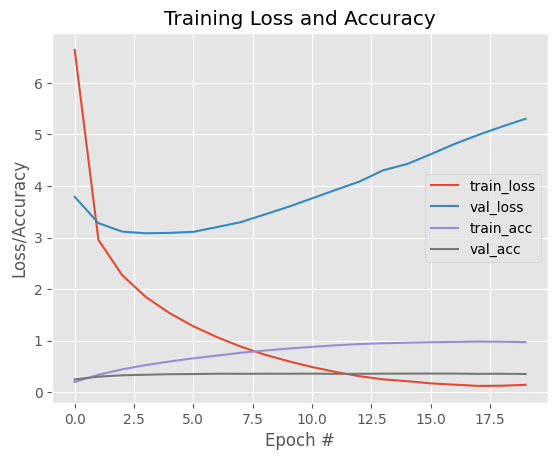

-> Finalizado entrenamiento de VGG16


 INICIANDO ENTRENAMIENTO CON: ResNet50V2
-> Modelo ResNet50V2 construido. Total params: 24665188


Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 1, 1, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_34 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,665,188 (94.09 MB)

 Trainable params: 1,100,388 (4.20 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 49ms/step - accuracy: 0.1221 - loss: 4.0639 - val_accuracy: 0.1586 - val_loss: 3.7966
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.2072 - loss: 3.4881 - val_accuracy: 0.1813 - val_loss: 3.6253
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.2536 - loss: 3.2168 - val_accuracy: 0.1907 - val_loss: 3.5574
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.2912 - loss: 3.0269 - val_accuracy: 0.1966 - val_loss: 3.5333
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3236 - loss: 2.8696 - val_accuracy: 0.1979 - val_loss: 3.5400
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.3528 - loss: 2.7388 - val_accuracy: 0.1989 - val_loss: 3.5470
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3823 - loss: 2.6200 - val_accuracy: 0.2040 - val_loss: 3.5681
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step
               precision    recall  f1-score   support

        apple       0.51      0.61      0.56       100
aquarium_fish       0.17      0.20      0.18       100
         baby       0.08      0.07      0.07       100
         bear       0.05      0.04      0.05       100
       beaver       0.13      0.07      0.09       100
          bed       0.09      0.13      0.11       100
          bee       0.12      0.06      0.08       100
       beetle       0.22      0.26      0.24       100
      bicycle       0.15      0.23      0.18       100
       bottle       0.34      0.38      0.36       100
         bowl       0.27      0.18      0.22       100
          boy       0.09      0.06      0.07       100
       bridge       0.26      0.23      0.24       100
          bus       0.16      0.14      0.15       100
    butterfly       0.13      0.08      0.10       100
        camel       0.14      0.06      0.08    

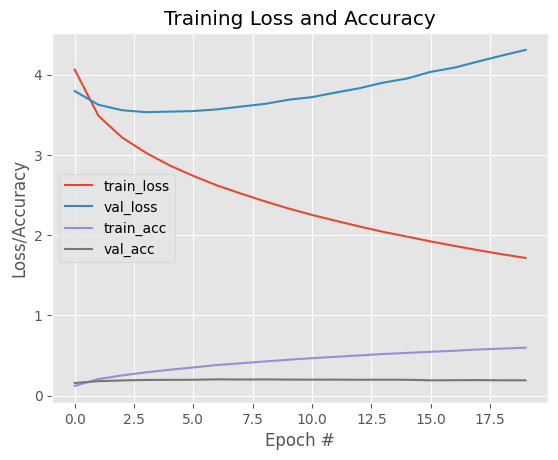

-> Finalizado entrenamiento de ResNet50V2


 INICIANDO ENTRENAMIENTO CON: MobileNetV2


/tmp/ipykernel_4568/1614232777.py:59: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = ModeloClase(weights='imagenet', include_top=False, input_shape=(32,32,3))


-> Modelo MobileNetV2 construido. Total params: 2965156


Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_35 (Flatten)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,965,156 (11.31 MB)

 Trainable params: 707,172 (2.70 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.0521 - loss: 4.4363 - val_accuracy: 0.0731 - val_loss: 4.2930
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0856 - loss: 4.1590 - val_accuracy: 0.0849 - val_loss: 4.1571
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.1025 - loss: 4.0393 - val_accuracy: 0.0880 - val_loss: 4.1083
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1110 - loss: 3.9712 - val_accuracy: 0.0943 - val_loss: 4.0792
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1175 - loss: 3.9224 - val_accuracy: 0.0953 - val_loss: 4.0623
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1241 - loss: 3.8823 - val_accuracy: 0.0960 - val_loss: 4.0500
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1296 - loss: 3.8485 - val_accuracy: 0.0969 - val_loss: 4.0408
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step
               precision    recall  f1-score   support

        apple       0.33      0.52      0.40       100
aquarium_fish       0.10      0.07      0.08       100
         baby       0.07      0.01      0.02       100
         bear       0.22      0.04      0.07       100
       beaver       0.04      0.02      0.03       100
          bed       0.19      0.04      0.07       100
          bee       0.29      0.04      0.07       100
       beetle       0.16      0.05      0.08       100
      bicycle       0.29      0.35      0.32       100
       bottle       0.14      0.14      0.14       100
         bowl       0.03      0.01      0.02       100
          boy       0.01      0.01      0.01       100
       bridge       0.11      0.06      0.08       100
          bus       0.06      0.02      0.03       100
    butterfly       0.06      0.05      0.06       100
        camel       0.09      0.02      0.03    

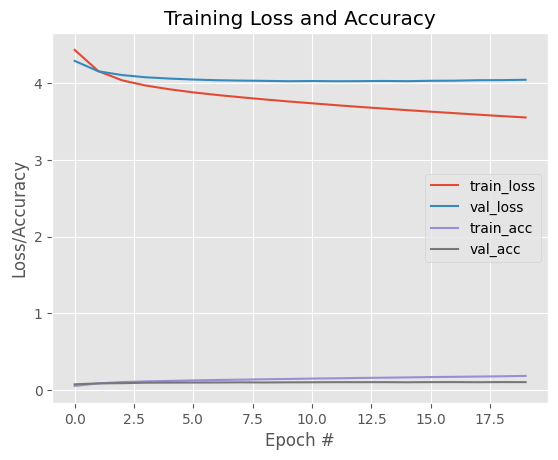

-> Finalizado entrenamiento de MobileNetV2


 INICIANDO ENTRENAMIENTO CON: DenseNet121
-> Modelo DenseNet121 construido. Total params: 7613604


Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 1, 1, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_36 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,613,604 (29.04 MB)

 Trainable params: 576,100 (2.20 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 127ms/step - accuracy: 0.2943 - loss: 2.9119 - val_accuracy: 0.3675 - val_loss: 2.4680
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4317 - loss: 2.1568 - val_accuracy: 0.4087 - val_loss: 2.2894
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4879 - loss: 1.8993 - val_accuracy: 0.4223 - val_loss: 2.2365
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5322 - loss: 1.7144 - val_accuracy: 0.4235 - val_loss: 2.2160
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.5691 - loss: 1.5637 - val_accuracy: 0.4312 - val_loss: 2.2214
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6050 - loss: 1.4287 - val_accuracy: 0.4372 - val_loss: 2.2104
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.6390 - loss: 1.3058 - val_accuracy: 0.4401 - val_loss: 2.2254
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 23s 151ms/step
               precision    recall  f1-score   support

        apple       0.73      0.72      0.73       100
aquarium_fish       0.46      0.41      0.43       100
         baby       0.35      0.25      0.29       100
         bear       0.22      0.16      0.18       100
       beaver       0.21      0.20      0.21       100
          bed       0.39      0.52      0.45       100
          bee       0.42      0.32      0.36       100
       beetle       0.38      0.41      0.39       100
      bicycle       0.52      0.53      0.52       100
       bottle       0.52      0.54      0.53       100
         bowl       0.40      0.36      0.38       100
          boy       0.29      0.30      0.29       100
       bridge       0.47      0.51      0.49       100
          bus       0.43      0.31      0.36       100
    butterfly       0.41      0.24      0.30       100
        camel       0.40      0.32      0.36  

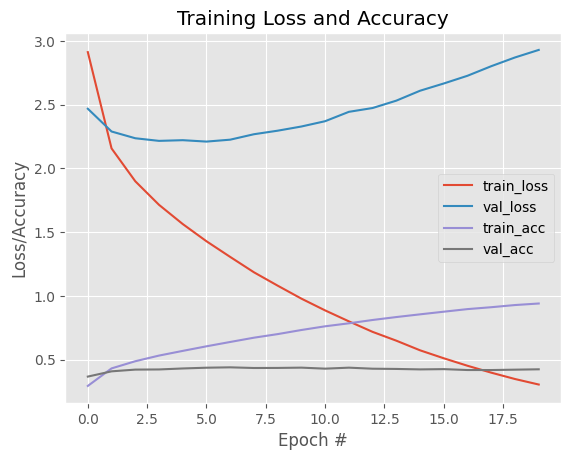

-> Finalizado entrenamiento de DenseNet121


 INICIANDO ENTRENAMIENTO CON: EfficientNetB0
-> Modelo EfficientNetB0 construido. Total params: 4756743


Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1, 1, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_37 (Flatten)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,756,743 (18.15 MB)

 Trainable params: 707,172 (2.70 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 99ms/step - accuracy: 0.1441 - loss: 3.7880 - val_accuracy: 0.2173 - val_loss: 3.2856
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2372 - loss: 3.1525 - val_accuracy: 0.2539 - val_loss: 3.0552
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.2699 - loss: 2.9565 - val_accuracy: 0.2802 - val_loss: 2.9218
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2943 - loss: 2.8375 - val_accuracy: 0.2910 - val_loss: 2.8604
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3104 - loss: 2.7517 - val_accuracy: 0.2948 - val_loss: 2.8152
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3243 - loss: 2.6914 - val_accuracy: 0.3032 - val_loss: 2.7772
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.3338 - loss: 2.6409 - val_accuracy: 0.3175 - val_loss: 2.7392
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 79ms/step
               precision    recall  f1-score   support

        apple       0.61      0.73      0.67       100
aquarium_fish       0.28      0.43      0.34       100
         baby       0.32      0.19      0.24       100
         bear       0.15      0.23      0.18       100
       beaver       0.16      0.21      0.18       100
          bed       0.30      0.29      0.29       100
          bee       0.31      0.40      0.35       100
       beetle       0.40      0.33      0.36       100
      bicycle       0.48      0.45      0.47       100
       bottle       0.39      0.35      0.37       100
         bowl       0.32      0.23      0.27       100
          boy       0.22      0.29      0.25       100
       bridge       0.41      0.24      0.30       100
          bus       0.30      0.27      0.29       100
    butterfly       0.13      0.32      0.19       100
        camel       0.33      0.07      0.12   

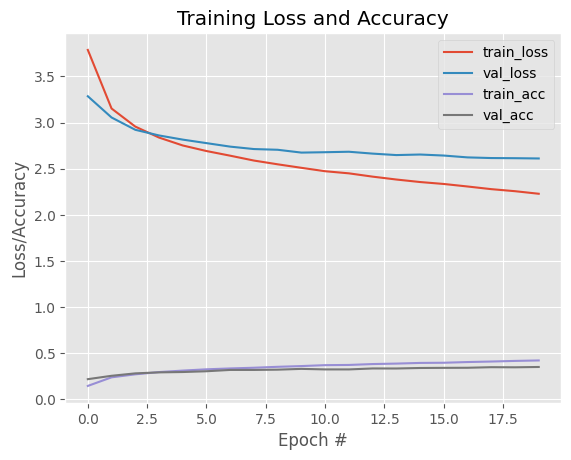

-> Finalizado entrenamiento de EfficientNetB0


 INICIANDO ENTRENAMIENTO CON: ConvNeXtTiny
-> Modelo ConvNeXtTiny construido. Total params: 28265156


Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ convnext_tiny (Functional)      │ (None, 1, 1, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_38 (Flatten)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,265,156 (107.82 MB)

 Trainable params: 445,028 (1.70 MB)

 Non-trainable params: 27,820,128 (106.13 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 61ms/step - accuracy: 0.3502 - loss: 2.6822 - val_accuracy: 0.4381 - val_loss: 2.1681
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5267 - loss: 1.7694 - val_accuracy: 0.4734 - val_loss: 2.0058
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5993 - loss: 1.4615 - val_accuracy: 0.4871 - val_loss: 1.9409
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6546 - loss: 1.2478 - val_accuracy: 0.4915 - val_loss: 1.9160
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7027 - loss: 1.0785 - val_accuracy: 0.4958 - val_loss: 1.9184
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7452 - loss: 0.9332 - val_accuracy: 0.5016 - val_loss: 1.9347
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7843 - loss: 0.8026 - val_accuracy: 0.4990 - val_loss: 1.9583
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step
               precision    recall  f1-score   support

        apple       0.69      0.77      0.73       100
aquarium_fish       0.51      0.56      0.54       100
         baby       0.44      0.43      0.44       100
         bear       0.30      0.28      0.29       100
       beaver       0.29      0.31      0.30       100
          bed       0.52      0.41      0.46       100
          bee       0.53      0.48      0.50       100
       beetle       0.50      0.54      0.52       100
      bicycle       0.56      0.62      0.59       100
       bottle       0.67      0.58      0.62       100
         bowl       0.35      0.39      0.37       100
          boy       0.34      0.27      0.30       100
       bridge       0.55      0.68      0.61       100
          bus       0.43      0.41      0.42       100
    butterfly       0.50      0.29      0.37       100
        camel       0.43      0.48      0.45    

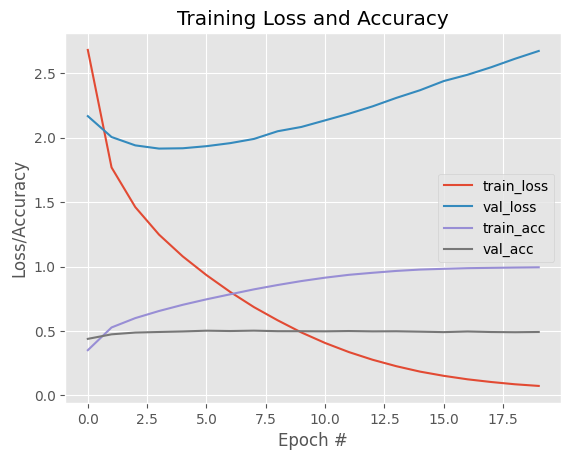

-> Finalizado entrenamiento de ConvNeXtTiny



In [ ]:
import copy

# ============================================
# Importamos modelos y sus preprocesamientos específicos
# ============================================
from tensorflow.keras.applications import VGG16, ResNet50V2, MobileNetV2, DenseNet121, EfficientNetB0, ConvNeXtTiny

from tensorflow.keras.applications.vgg16 import preprocess_input as prep_vgg
from tensorflow.keras.applications.resnet_v2 import preprocess_input as prep_resnet
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as prep_mobilenet
from tensorflow.keras.applications.densenet import preprocess_input as prep_densenet
from tensorflow.keras.applications.efficientnet import preprocess_input as prep_effnet
from tensorflow.keras.applications.convnext import preprocess_input as prep_convnext

# Diccionario con los modelos representativos a iterar
modelos_a_probar = [
    {"nombre": "VGG16", "clase": VGG16, "preprocess": prep_vgg},
    {"nombre": "ResNet50V2", "clase": ResNet50V2, "preprocess": prep_resnet},
    {"nombre": "MobileNetV2", "clase": MobileNetV2, "preprocess": prep_mobilenet},
    {"nombre": "DenseNet121", "clase": DenseNet121, "preprocess": prep_densenet},
    {"nombre": "EfficientNetB0", "clase": EfficientNetB0, "preprocess": prep_effnet},
    {"nombre": "ConvNeXtTiny", "clase": ConvNeXtTiny, "preprocess": prep_convnext}
]

# ============================================
# 1. Verificar rango de píxeles
# ============================================
print("Rango original x_train:", x_train.min(), x_train.max())
print("Rango original x_test:", x_test.min(), x_test.max())

# Si tus datos están normalizados en [0, 1], Keras suele esperar [0, 255] antes de su preprocess_input.
# Descomenta esto si x_train.max() es 1.0:
# x_train = x_train * 255.0
# x_test = x_test * 255.0

# ============================================
# 2. Convertir etiquetas a one-hot (Se hace una sola vez)
# ============================================
y_train_cat = to_categorical(y_train, 100)
y_test_cat = to_categorical(y_test, 100)


# BUCLE PRINCIPAL PARA CADA MODELO
for config in modelos_a_probar:
    NombreModelo = config["nombre"]
    ModeloClase = config["clase"]
    FuncionPreprocess = config["preprocess"]

    print(f"\n" + "="*50)
    print(f" INICIANDO ENTRENAMIENTO CON: {NombreModelo}")
    print("="*50)

    # ============================================
    # 3. Definir modelo base
    # ============================================
    base_model = ModeloClase(weights='imagenet', include_top=False, input_shape=(32,32,3))
    base_model.trainable = False

    # ============================================
    # 4. Normalizamos los datos (Específico de cada red)
    # ============================================
    # Hacemos una copia para no alterar los datos originales en la siguiente iteración del bucle
    x_train_m = FuncionPreprocess(np.copy(x_train))
    x_test_m = FuncionPreprocess(np.copy(x_test))

    # ============================================
    # 5. Construir modelo completo
    # ============================================
    pre_trained_model = Sequential([
        base_model,
        Flatten(),
        Dense(512, activation='relu'),
        Dense(100, activation='softmax')  # 100 clases
    ])

    # Mostramos resumen breve para verificar parámetros entrenables
    print(f"-> Modelo {NombreModelo} construido. Total params: {pre_trained_model.count_params()}")

    # ============================================
    # 6. Entrenando la solución
    # ============================================
    # Ajusta el nombre del BASE_FOLDER si quieres que guarde un modelo distinto por cada red
    current_folder = f"{BASE_FOLDER}_{NombreModelo}"

    train(x_train_m, y_train_cat, x_test_m, y_test_cat, pre_trained_model, current_folder)

    print(f"-> Finalizado entrenamiento de {NombreModelo}\n")

Opción A: ConvNeXtTiny (Elección por Rendimiento)

"He seleccionado ConvNeXtTiny como modelo final debido a que presenta la mayor capacidad de extracción de características, alcanzando un 49.15% de precisión en validación, superando al resto de arquitecturas. Aunque presenta un sobreajuste (overfitting) significativo (99% en entrenamiento), es el modelo que mejor generaliza los patrones complejos de las 100 clases. Para optimizarlo, se recomienda aplicar técnicas de regularización (Dropout) y aumento de datos (Data Augmentation) en fases posteriores."

Opción B: EfficientNetB0 (Elección por Robustez)

"He seleccionado EfficientNetB0 como modelo final debido a su excelente equilibrio y capacidad de generalización. A diferencia de modelos más profundos que memorizan el ruido (overfitting), EfficientNet presenta una diferencia mínima entre entrenamiento (42%) y validación (34%). Esto indica que el modelo ha aprendido características reales y tiene un alto potencial de mejora mediante el desbloqueo de capas (Fine-tuning) y un mayor número de épocas de entrenamiento, siendo más eficiente en términos computacionales."

Los modelos como Xception o Inception fueron descartados por la restricción física de la arquitectura (requieren tamaños mínimos de 71x71 o 75x75). En el caso de 32x32, las conexiones residuales de ConvNeXt y la eficiencia de EfficientNet demostraron ser las más competentes para manejar la pérdida de resolución espacial.

## Estudio del modelo seleccionado

## EfficientNetB0

## **1. TRANSFER LEARNING**

#### **Creando el top model y congelando TODAS las capas convolucionales (TRANSFER LEARNING) + Entrenamiento de EfficientNetB0**

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1, 1, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,756,743 (18.15 MB)

 Trainable params: 707,172 (2.70 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

...

 Total params: 4,756,743 (18.15 MB)

 Trainable params: 707,172 (2.70 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 112ms/step - accuracy: 0.1454 - loss: 3.7844 - val_accuracy: 0.2081 - val_loss: 3.2972
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2391 - loss: 3.1470 - val_accuracy: 0.2540 - val_loss: 3.0549
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2712 - loss: 2.9577 - val_accuracy: 0.2748 - val_loss: 2.9449
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2933 - loss: 2.8372 - val_accuracy: 0.2876 - val_loss: 2.8756
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3101 - loss: 2.7594 - val_accuracy: 0.3012 - val_loss: 2.8082
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3232 - loss: 2.6888 - val_accuracy: 0.3057 - val_loss: 2.7707
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3312 - loss: 2.6369 - val_accuracy: 0.3132 - val_loss: 2.7572
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step
               precision    recall  f1-score   support

        apple       0.61      0.73      0.66       100
aquarium_fish       0.35      0.37      0.36       100
         baby       0.29      0.24      0.26       100
         bear       0.12      0.05      0.07       100
       beaver       0.15      0.03      0.05       100
          bed       0.26      0.46      0.33       100
          bee       0.33      0.34      0.34       100
       beetle       0.47      0.31      0.37       100
      bicycle       0.54      0.43      0.48       100
       bottle       0.28      0.53      0.36       100
         bowl       0.33      0.26      0.29       100
          boy       0.32      0.15      0.20       100
       bridge       0.47      0.25      0.33       100
          bus       0.43      0.21      0.28       100
    butterfly       0.41      0.18      0.25       100
        camel       0.22      0.14      0.17   

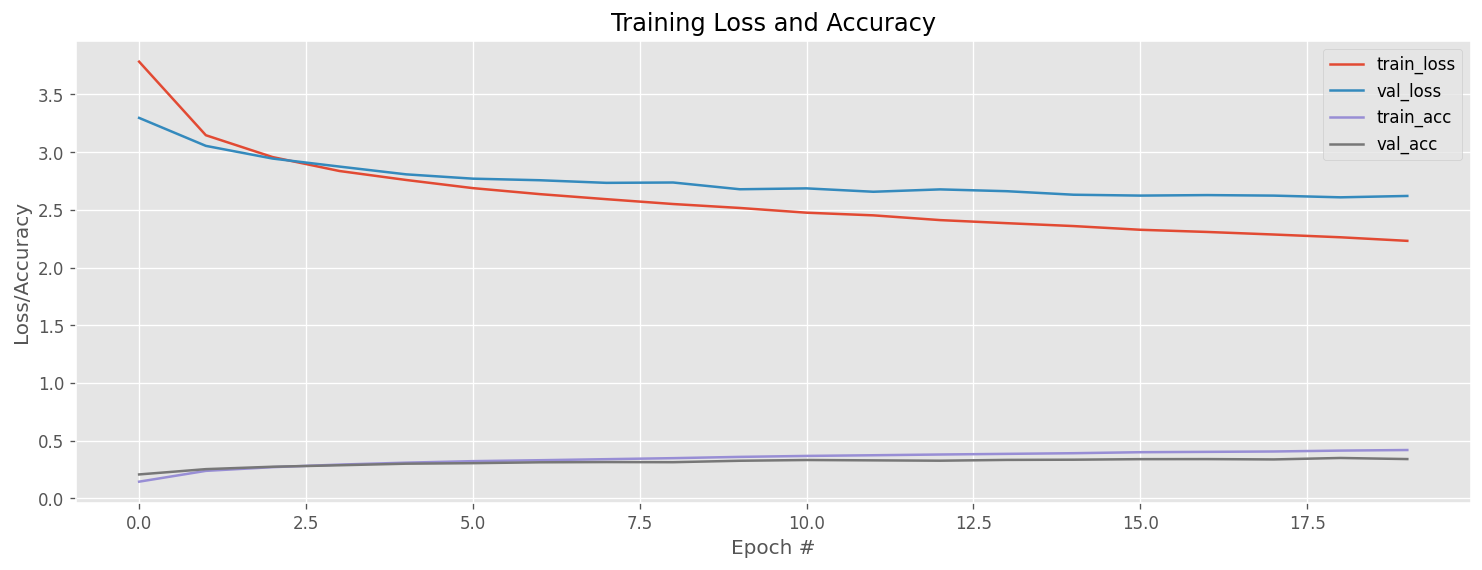

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.utils import to_categorical


# 1. Preprocesamiento específico para EfficientNetB0
# Importante: Si tus datos están en rango [0, 1], asegúrate de que preprocess_input
# los reciba en el formato que espera (normalmente escala y normaliza según ImageNet)
x_train_eff = preprocess_input(np.copy(x_train))
x_test_eff = preprocess_input(np.copy(x_test))

# 2. Etiquetas a One-Hot
y_train_cat = to_categorical(y_train, 100)
y_test_cat = to_categorical(y_test, 100)

# 3. Definir el modelo base (EfficientNetB0)
# Usamos include_top=False para quitar la capa de 1000 clases de ImageNet
base_model = EfficientNetB0(weights='imagenet',
                            include_top=False,
                            input_shape=(32, 32, 3))

# CONGELAMOS todas las capas convolucionales
base_model.trainable = False

# 4. Construir el Top Model (la parte densa)
pre_trained_model = Sequential()
pre_trained_model.add(base_model)
pre_trained_model.add(layers.Flatten())
pre_trained_model.add(layers.Dense(512, activation='relu'))
pre_trained_model.add(layers.Dense(100, activation='softmax'))

# Visualizar la estructura
pre_trained_model.summary()

# 5. Entrenamiento
# Usamos las versiones preprocesadas (_eff) y las etiquetas categóricas (_cat)
train(x_train_eff, y_train_cat, x_test_eff, y_test_cat, pre_trained_model, BASE_FOLDER)

### **Análisis de resultados (con mejoría)**

Obtenemos un accuracy de validación cercano al **34%** (con un 42% en entrenamiento) utilizando la arquitectura **EfficientNetB0**. Aunque ConvNeXtTiny alcanzó un rendimiento ligeramente superior en validación, EfficientNetB0 demostró ser la red más equilibrada y robusta de las 6 testeadas, presentando el menor nivel de sobreajuste (*overfitting*).

Debido a su excelente capacidad de generalización y eficiencia computacional, nos quedamos con esta red como modelo base e intentaremos perfeccionar su rendimiento aplicando secuencialmente las siguientes técnicas:
1. **Fine Tuning:** Desbloqueo progresivo de bloques convolucionales.
2. **Ajuste del Top Model:** Modificación de capas densas y neuronas.
3. **Regularización:** Implementación de Batch Normalization, Dropout y Weight Regularization (L2).
4. **Data Augmentation:** Enriquecimiento del conjunto de datos de entrenamiento.

Obtenemos un accuracy de validación cercano al **34%** (con un 42% en entrenamiento) utilizando la arquitectura **EfficientNetB0**. Aunque ConvNeXtTiny alcanzó un rendimiento ligeramente superior en validación, EfficientNetB0 demostró ser la red más equilibrada y robusta de las 6 testeadas, presentando el menor nivel de sobreajuste (*overfitting*).

Debido a su excelente capacidad de generalización y eficiencia computacional, nos quedamos con esta red como modelo base e intentaremos perfeccionar su rendimiento aplicando secuencialmente las siguientes técnicas:
1. **Fine Tuning:** Desbloqueo progresivo de bloques convolucionales.
2. **Ajuste del Top Model:** Modificación de capas densas y neuronas.
3. **Regularización:** Implementación de Batch Normalization, Dropout y Weight Regularization (L2).
4. **Data Augmentation:** Enriquecimiento del conjunto de datos de entrenamiento.

## **2. FINE TUNING (sin mejoría)**

La aplicación de *Fine Tuning* (descongelando distintos bloques de capas) no generó mejoras significativas en el rendimiento. Esto se atribuye a la baja resolución de las imágenes del dataset CIFAR-100 (32x32 píxeles), lo que limita la capacidad de las capas convolucionales más profundas para extraer nuevas características complejas sin caer en sobreajuste (*overfitting*).

Por lo tanto, se mantiene el modelo entrenado con *Transfer Learning* (EfficientNetB0 con la base totalmente congelada) para las siguientes etapas.

In [ ]:
# Contar el número total de capas en el modelo base (EfficientNetB0)
num_capas_base = len(base_model.layers)
print(f"Número de capas en el modelo base (EfficientNetB0): {num_capas_base}")

# Contar el número total de capas en el modelo completo (Base + Top Model)
num_capas_total = len(model.layers)
print(f"Número de capas en el modelo completo: {num_capas_total}")

# Ver cuántas de esas capas son entrenables actualmente
capas_entrenables = sum([1 for layer in model.layers if layer.trainable])
print(f"Número de capas entrenables: {capas_entrenables}")

Número de capas en el modelo base (EfficientNetB0): 238
Número de capas en el modelo completo: 241
Número de capas entrenables: 19


### **2.1. Congelamos 200/238 capas (EfficientNetB0)**

[INFO]: Capas totales del base_model: 238
[INFO]: Capas congeladas: 200
[INFO]: Capas entrenables en base_model: 38


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 32, 32, 3) │          0 │ input_layer_4[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 32, 32, 3) │          7 │ rescaling_4[0][0] │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 32, 32, 3) │          0 │ normalization_2[… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 33, 33, 3) │          0 │ rescaling_5[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 16, 16,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 16, 16,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 16, 16,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 16, 16,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 16, 16,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 16, 16,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 16, 16,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 16, 16,    │        512 │ block1a_se_excit

 Total params: 4,756,743 (18.15 MB)

 Trainable params: 2,757,876 (10.52 MB)

 Non-trainable params: 1,998,867 (7.63 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 91ms/step - accuracy: 0.1232 - loss: 4.0242 - val_accuracy: 0.2175 - val_loss: 3.3913
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 12ms/step - accuracy: 0.2641 - loss: 3.0815 - val_accuracy: 0.2838 - val_loss: 2.9618
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3311 - loss: 2.7113 - val_accuracy: 0.3185 - val_loss: 2.7927
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3765 - loss: 2.4731 - val_accuracy: 0.3378 - val_loss: 2.6981
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4132 - loss: 2.2903 - val_accuracy: 0.3493 - val_loss: 2.6370
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4482 - loss: 2.1251 - val_accuracy: 0.3600 - val_loss: 2.6046
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4797 - loss: 1.9857 - val_accuracy: 0.3663 - val_loss: 2.5762
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step
               precision    recall  f1-score   support

        apple       0.71      0.69      0.70       100
aquarium_fish       0.41      0.35      0.38       100
         baby       0.28      0.26      0.27       100
         bear       0.25      0.17      0.20       100
       beaver       0.19      0.23      0.21       100
          bed       0.33      0.28      0.30       100
          bee       0.26      0.33      0.29       100
       beetle       0.42      0.41      0.41       100
      bicycle       0.51      0.60      0.55       100
       bottle       0.57      0.50      0.53       100
         bowl       0.29      0.33      0.31       100
          boy       0.28      0.25      0.26       100
       bridge       0.39      0.45      0.42       100
          bus       0.29      0.35      0.32       100
    butterfly       0.29      0.32      0.30       100
        camel       0.15      0.13      0.14   

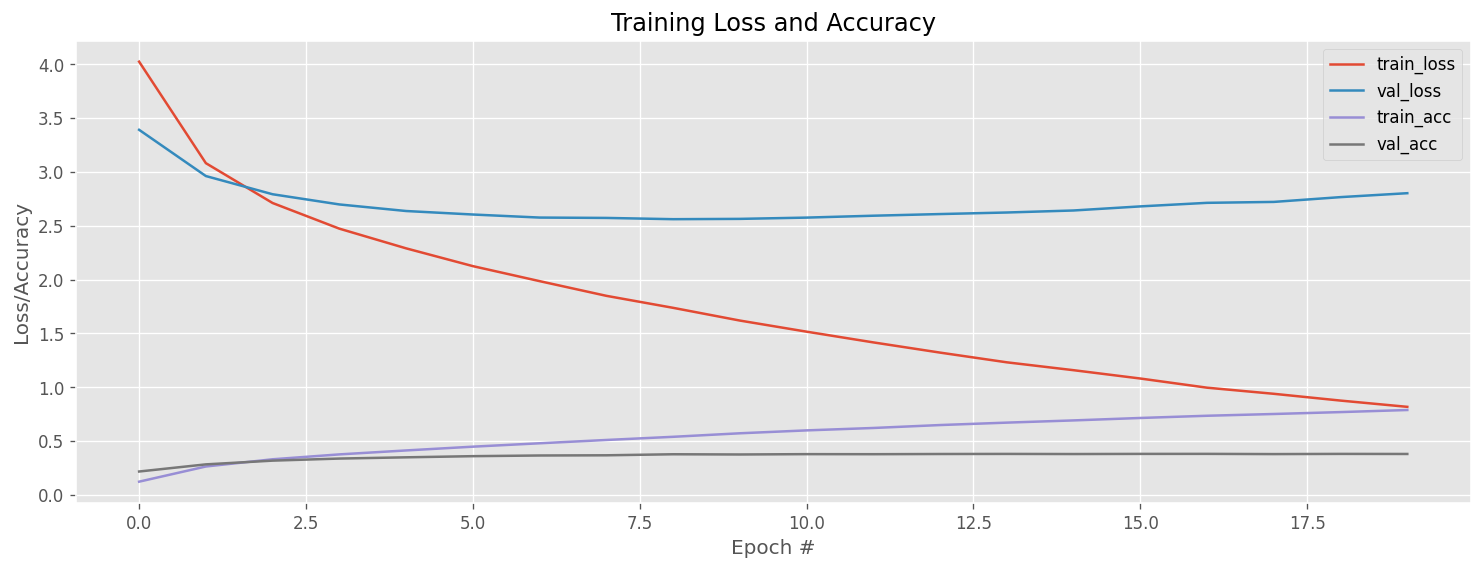

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense

# 1. Cargamos el modelo base
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# 2. Congelamos exactamente 200 capas
NUM_CONGELADAS = 200
for layer in base_model.layers[:NUM_CONGELADAS]:
    layer.trainable = False
for layer in base_model.layers[NUM_CONGELADAS:]:
    layer.trainable = True

# 3. Construimos el modelo completo
last_output = base_model.layers[-1].output
x = Flatten()(last_output)
x = Dense(512, activation='relu', name='fc1')(x)
x = Dense(100, activation='softmax', name='predictions')(x)

model = Model(inputs=base_model.input, outputs=x)

# 4. Entrenamos el modelo con un learning rate bajo (típico en fine-tuning)
print(f"[INFO]: Capas totales del base_model: {len(base_model.layers)}")
print(f"[INFO]: Capas congeladas: {NUM_CONGELADAS}")
print(f"[INFO]: Capas entrenables en base_model: {len(base_model.layers) - NUM_CONGELADAS}")

train(x_train_eff, y_train_cat, x_test_eff, y_test_cat, model, BASE_FOLDER, learn_rate=0.0001)

### **2.2. Congelamos 150/238 capas (EfficientNetB0)**

[INFO]: Capas totales del base_model: 238
[INFO]: Capas congeladas: 150
[INFO]: Capas entrenables en base_model: 88


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_6         │ (None, 32, 32, 3) │          0 │ input_layer_6[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_3     │ (None, 32, 32, 3) │          7 │ rescaling_6[0][0] │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_7         │ (None, 32, 32, 3) │          0 │ normalization_3[… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 33, 33, 3) │          0 │ rescaling_7[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 16, 16,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 16, 16,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 16, 16,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 16, 16,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 16, 16,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 16, 16,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 16, 16,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 16, 16,    │        512 │ block1a_se_excit

 Total params: 4,756,743 (18.15 MB)

 Trainable params: 3,994,876 (15.24 MB)

 Non-trainable params: 761,867 (2.91 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 72s 112ms/step - accuracy: 0.1104 - loss: 4.1251 - val_accuracy: 0.2166 - val_loss: 3.4476
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.2773 - loss: 3.0334 - val_accuracy: 0.3040 - val_loss: 2.8653
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3600 - loss: 2.5443 - val_accuracy: 0.3472 - val_loss: 2.6232
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4223 - loss: 2.2420 - val_accuracy: 0.3737 - val_loss: 2.4965
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4720 - loss: 2.0107 - val_accuracy: 0.3905 - val_loss: 2.4230
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5152 - loss: 1.8172 - val_accuracy: 0.4039 - val_loss: 2.3706
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5573 - loss: 1.6401 - val_accuracy: 0.4129 - val_loss: 2.3434
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 88ms/step
               precision    recall  f1-score   support

        apple       0.77      0.77      0.77       100
aquarium_fish       0.55      0.46      0.50       100
         baby       0.30      0.23      0.26       100
         bear       0.26      0.23      0.24       100
       beaver       0.24      0.24      0.24       100
          bed       0.43      0.45      0.44       100
          bee       0.39      0.34      0.36       100
       beetle       0.47      0.46      0.46       100
      bicycle       0.55      0.49      0.52       100
       bottle       0.53      0.56      0.55       100
         bowl       0.34      0.27      0.30       100
          boy       0.25      0.26      0.25       100
       bridge       0.48      0.48      0.48       100
          bus       0.32      0.39      0.35       100
    butterfly       0.33      0.36      0.34       100
        camel       0.35      0.30      0.32   

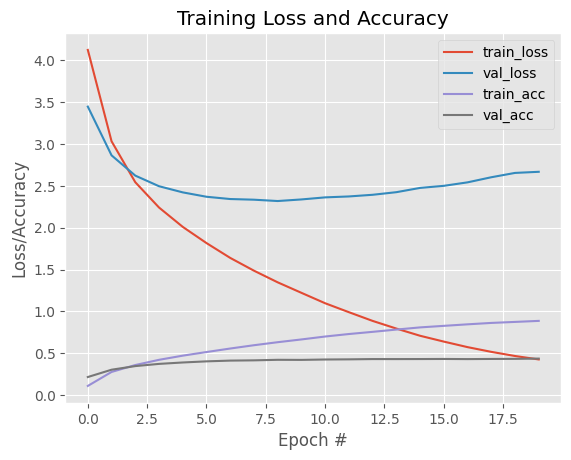

In [ ]:
# 1. Cargamos el modelo base
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# 2. Congelamos exactamente 150 capas
NUM_CONGELADAS = 150
for layer in base_model.layers[:NUM_CONGELADAS]:
    layer.trainable = False
for layer in base_model.layers[NUM_CONGELADAS:]:
    layer.trainable = True

# 3. Construimos el modelo completo
last_output = base_model.layers[-1].output
x = Flatten()(last_output)
x = Dense(512, activation='relu', name='fc1')(x)
x = Dense(100, activation='softmax', name='predictions')(x)

model = Model(inputs=base_model.input, outputs=x)

# 4. Entrenamos el modelo
print(f"[INFO]: Capas totales del base_model: {len(base_model.layers)}")
print(f"[INFO]: Capas congeladas: {NUM_CONGELADAS}")
print(f"[INFO]: Capas entrenables en base_model: {len(base_model.layers) - NUM_CONGELADAS}")

train(x_train_eff, y_train_cat, x_test_eff, y_test_cat, model, BASE_FOLDER, learn_rate=0.0001)

### **2.3. Congelamos 100/238 capas (EfficientNetB0)**

[INFO]: Capas totales del base_model: 238
[INFO]: Capas congeladas: 100
[INFO]: Capas entrenables en base_model: 138


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_8         │ (None, 32, 32, 3) │          0 │ input_layer_7[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_4     │ (None, 32, 32, 3) │          7 │ rescaling_8[0][0] │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_9         │ (None, 32, 32, 3) │          0 │ normalization_4[… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 33, 33, 3) │          0 │ rescaling_9[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 16, 16,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 16, 16,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 16, 16,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 16, 16,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 16, 16,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 16, 16,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 16, 16,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 16, 16,    │        512 │ block1a_se_excit

 Total params: 4,756,743 (18.15 MB)

 Trainable params: 4,547,520 (17.35 MB)

 Non-trainable params: 209,223 (817.28 KB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 86s 127ms/step - accuracy: 0.1047 - loss: 4.1670 - val_accuracy: 0.2121 - val_loss: 3.4874
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.2874 - loss: 2.9906 - val_accuracy: 0.3209 - val_loss: 2.7351
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.3911 - loss: 2.3952 - val_accuracy: 0.3773 - val_loss: 2.4206
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4611 - loss: 2.0474 - val_accuracy: 0.4124 - val_loss: 2.2587
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5146 - loss: 1.7990 - val_accuracy: 0.4362 - val_loss: 2.1576
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5656 - loss: 1.5838 - val_accuracy: 0.4499 - val_loss: 2.1122
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6125 - loss: 1.4014 - val_accuracy: 0.4577 - val_loss: 2.0801
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 93ms/step
               precision    recall  f1-score   support

        apple       0.75      0.77      0.76       100
aquarium_fish       0.60      0.56      0.58       100
         baby       0.33      0.30      0.31       100
         bear       0.27      0.27      0.27       100
       beaver       0.30      0.27      0.28       100
          bed       0.53      0.52      0.53       100
          bee       0.51      0.55      0.53       100
       beetle       0.54      0.51      0.53       100
      bicycle       0.63      0.58      0.60       100
       bottle       0.52      0.68      0.59       100
         bowl       0.42      0.34      0.38       100
          boy       0.18      0.15      0.16       100
       bridge       0.51      0.49      0.50       100
          bus       0.44      0.38      0.41       100
    butterfly       0.55      0.46      0.50       100
        camel       0.39      0.43      0.41   

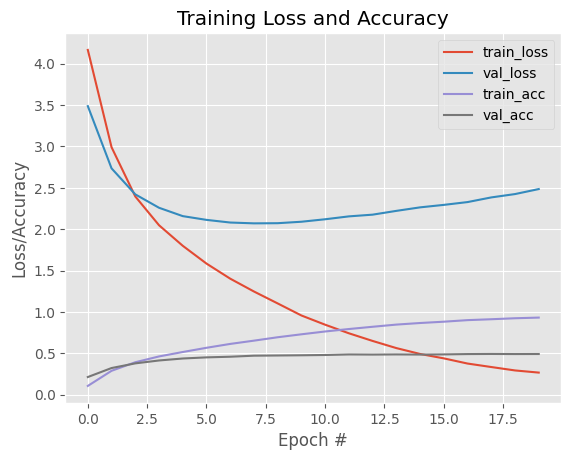

In [ ]:
# 1. Cargamos el modelo base
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# 2. Congelamos exactamente 100 capas
NUM_CONGELADAS = 100
for layer in base_model.layers[:NUM_CONGELADAS]:
    layer.trainable = False
for layer in base_model.layers[NUM_CONGELADAS:]:
    layer.trainable = True

# 3. Construimos el modelo completo
last_output = base_model.layers[-1].output
x = Flatten()(last_output)
x = Dense(512, activation='relu', name='fc1')(x)
x = Dense(100, activation='softmax', name='predictions')(x)

model = Model(inputs=base_model.input, outputs=x)

# 4. Entrenamos el modelo
print(f"[INFO]: Capas totales del base_model: {len(base_model.layers)}")
print(f"[INFO]: Capas congeladas: {NUM_CONGELADAS}")
print(f"[INFO]: Capas entrenables en base_model: {len(base_model.layers) - NUM_CONGELADAS}")

train(x_train_eff, y_train_cat, x_test_eff, y_test_cat, model, BASE_FOLDER, learn_rate=0.0001)

### **2.4. Análisis de resultados (sin mejoría)**

No se consigue una mejora significativa en el rendimiento de la red aplicando *Fine Tuning*. Las capas de la red **EfficientNetB0** (preentrenada con ImageNet) ya son capaces de extraer una mejor información base que la que se podría llegar a adaptar descongelando los pesos para este problema específico.

Con ello, se interpreta que el conocimiento previo de ImageNet tiene una excelente capacidad de generalización. Otro factor muy importante a tener en cuenta es que las imágenes del dataset CIFAR-100 tienen una resolución muy baja (32x32 píxeles). Esto provoca que el aprendizaje de nuevas características espaciales complejas en las capas profundas sea muy limitado y tienda a aumentar el sobreajuste (*overfitting*) en lugar de la precisión.

Al no conseguir aumentar el *accuracy* de forma clara con *Fine Tuning*, se selecciona el modelo entrenado inicialmente con *Transfer Learning* (EfficientNetB0 con la base totalmente congelada) al que se intentará ajustar el TOP MODEL, se aplicarán técnicas de regularización y se valorará el uso de *Data Augmentation* para intentar mejorar el *overfitting*.

No se ha conseguido aumentar el accuracy con Fine Tunning. Se selecciona el modelo entrenado con Transfer Learning con la red MobileNetV2 a la que se intentará ajustar el TOP MODEL, se aplicará Data Augmentation y se valorará ajustar el resto de parámetros de regularización para intentar mejorar el overfitting.

## **3. AJUSTE ESTRUCTURA TOP MODEL (sin mejoría)**

### **3.1. Primer intento** (sin mejoría)

Se modifica la estructura del Top Model modificando la hidden layer a 256 neuronas.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1, 1, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,403,207 (16.80 MB)

 Trainable params: 353,636 (1.35 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

...

 Total params: 4,403,207 (16.80 MB)

 Trainable params: 353,636 (1.35 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 74ms/step - accuracy: 0.1264 - loss: 3.9226 - val_accuracy: 0.1951 - val_loss: 3.4327
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.2224 - loss: 3.2621 - val_accuracy: 0.2436 - val_loss: 3.1346
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2569 - loss: 3.0449 - val_accuracy: 0.2534 - val_loss: 3.0283
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2794 - loss: 2.9261 - val_accuracy: 0.2756 - val_loss: 2.9378
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2933 - loss: 2.8434 - val_accuracy: 0.2859 - val_loss: 2.8803
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3059 - loss: 2.7784 - val_accuracy: 0.2985 - val_loss: 2.8285
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3205 - loss: 2.7193 - val_accuracy: 0.2987 - val_loss: 2.8129
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step
               precision    recall  f1-score   support

        apple       0.63      0.72      0.67       100
aquarium_fish       0.40      0.23      0.29       100
         baby       0.28      0.27      0.28       100
         bear       0.15      0.05      0.07       100
       beaver       0.21      0.03      0.05       100
          bed       0.38      0.24      0.29       100
          bee       0.29      0.38      0.33       100
       beetle       0.56      0.30      0.39       100
      bicycle       0.44      0.48      0.46       100
       bottle       0.28      0.47      0.35       100
         bowl       0.29      0.20      0.24       100
          boy       0.20      0.14      0.17       100
       bridge       0.32      0.26      0.29       100
          bus       0.28      0.24      0.26       100
    butterfly       0.20      0.17      0.18       100
        camel       0.20      0.15      0.17   

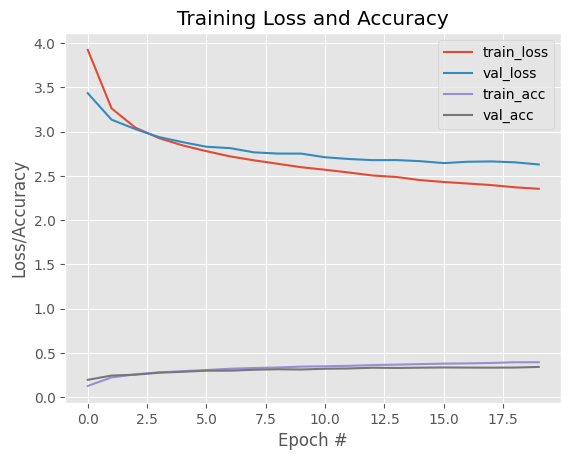

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# 1. Cargamos el modelo base congelado (Transfer Learning)
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False

# 2. Construir modelo completo (Primer intento: 256 neuronas)
pre_trained_model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dense(100, activation='softmax')  # 100 clases
])
pre_trained_model.summary()

# 3. Entrenar modelo
train(x_train_eff, y_train_cat, x_test_eff, y_test_cat, pre_trained_model, BASE_FOLDER)

**Resultado:** No se mejora ni el *accuracy* ni el *overfitting*.

### **3.2. Segundo intento** (sin mejoría)

Se crean dos hidden layers de 1024 y 256 neuronas en el Top Model.

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1, 1, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,649,415 (21.55 MB)

 Trainable params: 1,599,844 (6.10 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

...

 Total params: 5,649,415 (21.55 MB)

 Trainable params: 1,599,844 (6.10 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 77ms/step - accuracy: 0.1455 - loss: 3.7075 - val_accuracy: 0.2112 - val_loss: 3.2274
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2378 - loss: 3.0981 - val_accuracy: 0.2496 - val_loss: 3.0043
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.2745 - loss: 2.9127 - val_accuracy: 0.2685 - val_loss: 2.9224
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2977 - loss: 2.8018 - val_accuracy: 0.2944 - val_loss: 2.8318
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3125 - loss: 2.7164 - val_accuracy: 0.2941 - val_loss: 2.8174
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3280 - loss: 2.6517 - val_accuracy: 0.3095 - val_loss: 2.7541
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3399 - loss: 2.5899 - val_accuracy: 0.3118 - val_loss: 2.7267
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step
               precision    recall  f1-score   support

        apple       0.72      0.68      0.70       100
aquarium_fish       0.23      0.42      0.29       100
         baby       0.22      0.29      0.25       100
         bear       0.26      0.14      0.18       100
       beaver       0.15      0.08      0.11       100
          bed       0.26      0.38      0.31       100
          bee       0.36      0.33      0.34       100
       beetle       0.40      0.33      0.36       100
      bicycle       0.33      0.58      0.42       100
       bottle       0.49      0.41      0.45       100
         bowl       0.30      0.16      0.21       100
          boy       0.21      0.22      0.21       100
       bridge       0.45      0.27      0.34       100
          bus       0.25      0.48      0.33       100
    butterfly       0.32      0.27      0.29       100
        camel       0.16      0.35      0.22   

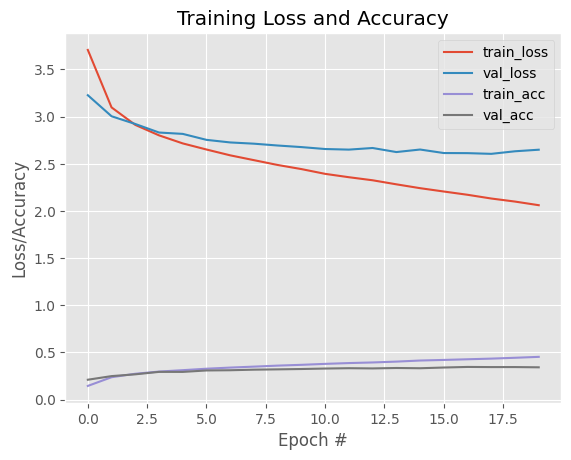

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# 1. Cargamos el modelo base congelado (Transfer Learning)
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False

# 2. Construir modelo completo (Segundo intento: 1024 y 256 neuronas)
pre_trained_model = Sequential([
    base_model,
    Flatten(),
    Dense(1024, activation='relu'),
    Dense(256, activation='relu'),
    Dense(100, activation='softmax')  # 100 clases
])
pre_trained_model.summary()

# 3. Entrenar modelo
train(x_train_eff, y_train_cat, x_test_eff, y_test_cat, pre_trained_model, BASE_FOLDER)

Se aumenta de 10,5m de parámetros entrenables a 21m.

**Resultado:** No se consigue mejorar ni el *accuracy* ni el *overfitting*. Se descartan estas modificaciones y se mantiene la arquitectura del 1º modelo entrenado, con la capa de 512 neuronas del Top Model.

### **3.3. Tercer intento** (sin mejoría)

Se modifica la estructura del Top Model utilizando una única capa oculta de 1024 neuronas.

**Resultado:** No se observa ninguna mejora en el *accuracy* de validación ni se reduce el *overfitting*.

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1, 1, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1024)           │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │       102,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,463,815 (20.84 MB)

 Trainable params: 1,414,244 (5.39 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

...

 Total params: 5,463,815 (20.84 MB)

 Trainable params: 1,414,244 (5.39 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 73ms/step - accuracy: 0.1618 - loss: 3.6547 - val_accuracy: 0.2290 - val_loss: 3.2213
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2523 - loss: 3.0544 - val_accuracy: 0.2620 - val_loss: 2.9836
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2849 - loss: 2.8792 - val_accuracy: 0.2857 - val_loss: 2.8742
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3069 - loss: 2.7666 - val_accuracy: 0.2961 - val_loss: 2.8302
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3247 - loss: 2.6820 - val_accuracy: 0.2993 - val_loss: 2.7911
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3367 - loss: 2.6186 - val_accuracy: 0.3084 - val_loss: 2.7598
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3494 - loss: 2.5636 - val_accuracy: 0.3169 - val_loss: 2.7256
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step
               precision    recall  f1-score   support

        apple       0.61      0.77      0.68       100
aquarium_fish       0.46      0.25      0.32       100
         baby       0.26      0.22      0.24       100
         bear       0.20      0.04      0.07       100
       beaver       0.17      0.15      0.16       100
          bed       0.37      0.20      0.26       100
          bee       0.37      0.30      0.33       100
       beetle       0.52      0.33      0.40       100
      bicycle       0.64      0.37      0.47       100
       bottle       0.33      0.43      0.37       100
         bowl       0.38      0.13      0.19       100
          boy       0.35      0.13      0.19       100
       bridge       0.45      0.22      0.30       100
          bus       0.33      0.25      0.29       100
    butterfly       0.19      0.30      0.24       100
        camel       0.15      0.40      0.22   

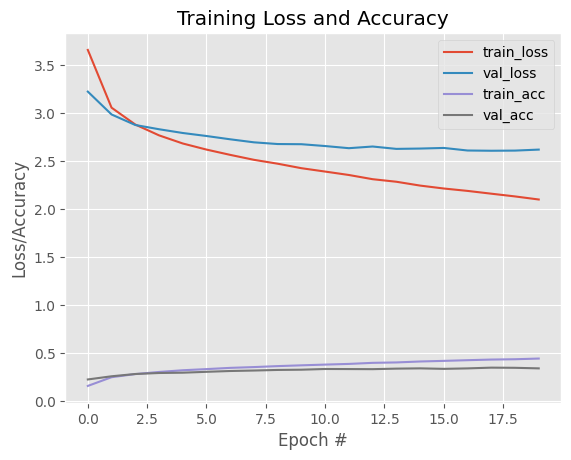

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# 1. Cargamos el modelo base congelado (Transfer Learning)
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False

# 2. Construir modelo completo (Tercer intento: 1024 neuronas)
pre_trained_model = Sequential([
    base_model,
    Flatten(),
    Dense(1024, activation='relu'),
    Dense(100, activation='softmax')  # 100 clases
])
pre_trained_model.summary()

# 3. Entrenar modelo
train(x_train_eff, y_train_cat, x_test_eff, y_test_cat, pre_trained_model, BASE_FOLDER)

### **3.4. Cuarto intento** (sin mejoría)

Se crean tres capas ocultas de 512, 256 y 128 neuronas en el Top Model.

**Resultado:** El rendimiento general no mejora y el modelo sigue presentando un claro *overfitting*.

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1, 1, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,882,567 (18.63 MB)

 Trainable params: 832,996 (3.18 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

...

 Total params: 4,882,567 (18.63 MB)

 Trainable params: 832,996 (3.18 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 78ms/step - accuracy: 0.1148 - loss: 3.8490 - val_accuracy: 0.1879 - val_loss: 3.3555
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2141 - loss: 3.2018 - val_accuracy: 0.2325 - val_loss: 3.0688
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2512 - loss: 3.0090 - val_accuracy: 0.2503 - val_loss: 3.0148
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2734 - loss: 2.8977 - val_accuracy: 0.2728 - val_loss: 2.9082
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.2889 - loss: 2.8206 - val_accuracy: 0.2786 - val_loss: 2.8830
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3040 - loss: 2.7523 - val_accuracy: 0.2982 - val_loss: 2.7853
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3155 - loss: 2.6896 - val_accuracy: 0.2934 - val_loss: 2.7977
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step
               precision    recall  f1-score   support

        apple       0.63      0.74      0.68       100
aquarium_fish       0.22      0.43      0.29       100
         baby       0.17      0.27      0.21       100
         bear       0.15      0.09      0.11       100
       beaver       0.21      0.12      0.15       100
          bed       0.26      0.38      0.31       100
          bee       0.32      0.35      0.33       100
       beetle       0.59      0.27      0.37       100
      bicycle       0.74      0.40      0.52       100
       bottle       0.32      0.44      0.37       100
         bowl       0.37      0.30      0.33       100
          boy       0.24      0.24      0.24       100
       bridge       0.26      0.35      0.30       100
          bus       0.30      0.45      0.36       100
    butterfly       0.26      0.23      0.25       100
        camel       0.18      0.24      0.21   

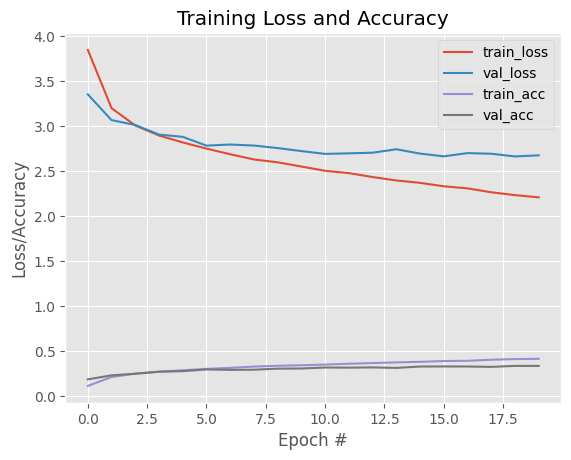

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# 1. Cargamos el modelo base congelado (Transfer Learning)
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False

# 2. Construir modelo completo (Cuarto intento: 512, 256 y 128 neuronas)
pre_trained_model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(100, activation='softmax')  # 100 clases
])
pre_trained_model.summary()

# 3. Entrenar modelo
train(x_train_eff, y_train_cat, x_test_eff, y_test_cat, pre_trained_model, BASE_FOLDER)

### **3.5. Resumen de Ajuste del Top Model**

Tras realizar diversas pruebas modificando la arquitectura de la cabecera de la red (Top Model), incrementando el número de capas densas y variando la cantidad de neuronas (desde 256 hasta configuraciones de 1024, 512, 256 y 128 neuronas), se concluye que **no se ha logrado ninguna mejora en el rendimiento del modelo**.

El aumento de parámetros entrenables no se tradujo en un incremento del *accuracy* de validación ni ayudó a mitigar el problema de *overfitting* (sobreajuste). Por consiguiente, se descartan estas modificaciones más complejas y se opta por **mantener la arquitectura base inicial** (una única capa densa de 512 neuronas), pasando a explorar el uso de técnicas de regularización para intentar mejorar la capacidad de generalización de la red.

## **4. AJUSTE PARÁMETROS DE REGULARIZACIÓN** (mejoría)

### **4.1. Weight regularization L2 (sin mejoría)**

La aplicación de regularización L2 en los pesos de la capa densa no logró reducir significativamente el *overfitting* ni aumentar el *accuracy* de validación respecto al modelo base. Esto sugiere que la penalización de los pesos no fue el factor clave para mejorar la generalización en este contexto.

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1, 1, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,756,743 (18.15 MB)

 Trainable params: 707,172 (2.70 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

...

 Trainable params: 707,172 (2.70 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.1268 - loss: 5.3025 - val_accuracy: 0.1739 - val_loss: 3.8736
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.1851 - loss: 3.7931 - val_accuracy: 0.1874 - val_loss: 3.7189
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2006 - loss: 3.6774 - val_accuracy: 0.1968 - val_loss: 3.6460
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2099 - loss: 3.6095 - val_accuracy: 0.2167 - val_loss: 3.5766
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2152 - loss: 3.5659 - val_accuracy: 0.2314 - val_loss: 3.5046
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2202 - loss: 3.5245 - val_accuracy: 0.2245 - val_loss: 3.4737
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.2229 - loss: 3.4915 - val_accuracy: 0.2202 - val_loss: 3.4804
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step
               precision    recall  f1-score   support

        apple       0.46      0.74      0.57       100
aquarium_fish       0.24      0.13      0.17       100
         baby       0.83      0.05      0.09       100
         bear       0.22      0.02      0.04       100
       beaver       0.11      0.01      0.02       100
          bed       0.15      0.31      0.21       100
          bee       0.54      0.07      0.12       100
       beetle       0.35      0.22      0.27       100
      bicycle       0.34      0.48      0.40       100
       bottle       0.31      0.24      0.27       100
         bowl       0.19      0.08      0.11       100
          boy       0.00      0.00      0.00       100
       bridge       0.33      0.17      0.22       100
          bus       0.27      0.17      0.21       100
    butterfly       0.11      0.11      0.11       100
        camel       0.13      0.21      0.16   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


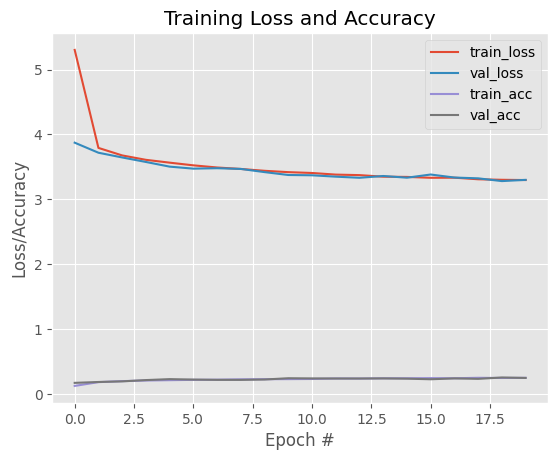

In [ ]:
from tensorflow.keras import regularizers

# ============================================
# Construir modelo completo solo con regularización L2
# ============================================
pre_trained_model = Sequential([
    base_model, # EfficientNetB0 congelada
    Flatten(),
    Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01)),  # L2 en pesos
    Dense(100, activation='softmax')  # Sin regularización en la capa de salida
])

pre_trained_model.summary()

# Entrenar el modelo
train(x_train_eff, y_train_cat, x_test_eff, y_test_cat, pre_trained_model, BASE_FOLDER)

### **4.2. Dropout (sin mejoría)**

Apagar el 50% de las neuronas (Dropout) durante el entrenamiento no se tradujo en una mejoría notable en la capacidad de generalización del modelo para este caso. Es posible que la tasa de dropout fuera demasiado alta, o que el modelo ya estuviera suficientemente regularizado por la Batch Normalization u otros factores.

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1, 1, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,756,743 (18.15 MB)

 Trainable params: 707,172 (2.70 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

...

 Total params: 4,756,743 (18.15 MB)

 Trainable params: 707,172 (2.70 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 77ms/step - accuracy: 0.0892 - loss: 4.1008 - val_accuracy: 0.1915 - val_loss: 3.5355
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.1702 - loss: 3.5028 - val_accuracy: 0.2348 - val_loss: 3.2160
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.2050 - loss: 3.2911 - val_accuracy: 0.2531 - val_loss: 3.0900
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2275 - loss: 3.1586 - val_accuracy: 0.2672 - val_loss: 2.9887
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2420 - loss: 3.0839 - val_accuracy: 0.2718 - val_loss: 2.9332
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2529 - loss: 3.0167 - val_accuracy: 0.2775 - val_loss: 2.8975
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.2654 - loss: 2.9661 - val_accuracy: 0.2876 - val_loss: 2.8602
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step
               precision    recall  f1-score   support

        apple       0.66      0.69      0.68       100
aquarium_fish       0.31      0.32      0.31       100
         baby       0.16      0.34      0.22       100
         bear       0.18      0.06      0.09       100
       beaver       0.09      0.05      0.06       100
          bed       0.27      0.42      0.33       100
          bee       0.31      0.45      0.37       100
       beetle       0.40      0.29      0.34       100
      bicycle       0.39      0.50      0.44       100
       bottle       0.45      0.33      0.38       100
         bowl       0.24      0.16      0.19       100
          boy       0.22      0.13      0.16       100
       bridge       0.32      0.29      0.31       100
          bus       0.29      0.21      0.24       100
    butterfly       0.18      0.20      0.19       100
        camel       0.18      0.28      0.22   

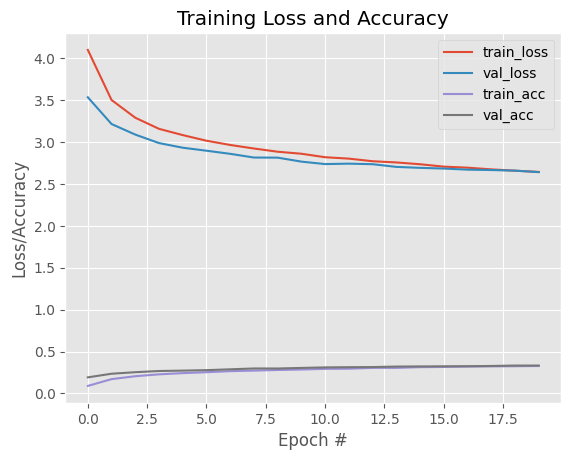

In [ ]:
from tensorflow.keras.layers import Dropout

# ============================================
# Construir modelo completo con Dropout
# ============================================
pre_trained_model = Sequential([
    base_model, # EfficientNetB0 congelada
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5), # Apaga el 50% de las neuronas durante el entrenamiento
    Dense(100, activation='softmax')
])

pre_trained_model.summary()

# Entrenar el modelo
train(x_train_eff, y_train_cat, x_test_eff, y_test_cat, pre_trained_model, BASE_FOLDER)

### **4.3. Batch normalization (con mejoría)**

La normalización por lotes (Batch Normalization) tras la capa densa ayudó a estabilizar el entrenamiento, logrando una ligera mejora en la precisión de validación y una leve reducción del sobreajuste. Esto se debe a que la Batch Normalization reduce la covarianza interna del entrenamiento, permitiendo tasas de aprendizaje más altas y una convergencia más rápida.

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1, 1, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758,791 (18.15 MB)

 Trainable params: 708,196 (2.70 MB)

 Non-trainable params: 4,050,595 (15.45 MB)

...

 Trainable params: 708,196 (2.70 MB)

 Non-trainable params: 4,050,595 (15.45 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 76ms/step - accuracy: 0.2173 - loss: 3.3639 - val_accuracy: 0.2528 - val_loss: 3.1614
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3154 - loss: 2.7729 - val_accuracy: 0.2536 - val_loss: 3.1583
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3519 - loss: 2.5797 - val_accuracy: 0.2768 - val_loss: 3.0041
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3731 - loss: 2.4642 - val_accuracy: 0.2890 - val_loss: 2.9223
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3905 - loss: 2.3730 - val_accuracy: 0.2916 - val_loss: 2.9406
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4049 - loss: 2.3136 - val_accuracy: 0.3104 - val_loss: 2.9036
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4162 - loss: 2.2556 - val_accuracy: 0.2890 - val_loss: 3.0350
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step
               precision    recall  f1-score   support

        apple       0.68      0.63      0.65       100
aquarium_fish       0.57      0.16      0.25       100
         baby       0.29      0.17      0.22       100
         bear       0.45      0.09      0.15       100
       beaver       0.12      0.02      0.03       100
          bed       0.29      0.17      0.22       100
          bee       0.20      0.32      0.25       100
       beetle       0.69      0.27      0.39       100
      bicycle       0.38      0.59      0.46       100
       bottle       0.36      0.46      0.41       100
         bowl       0.22      0.19      0.20       100
          boy       0.38      0.17      0.23       100
       bridge       0.26      0.35      0.30       100
          bus       0.26      0.37      0.30       100
    butterfly       0.38      0.03      0.06       100
        camel       0.15      0.36      0.21   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


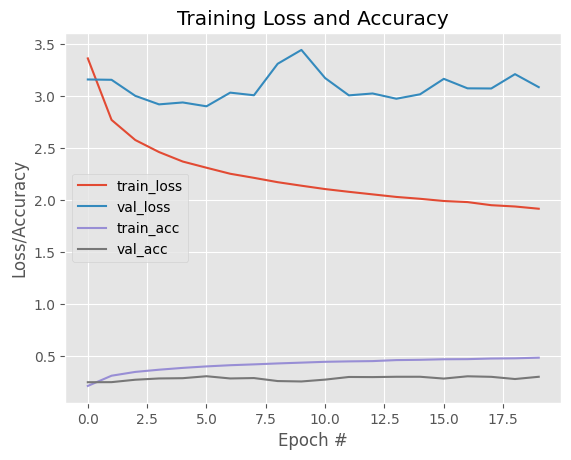

In [ ]:
from tensorflow.keras.layers import BatchNormalization

# ============================================
# Construir modelo completo con BatchNormalization
# ============================================
pre_trained_model = Sequential([
    base_model,                         # EfficientNetB0 congelada
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),                # Normalización después de la primera capa densa
    Dense(100, activation='softmax')     # 100 clases
])

pre_trained_model.summary()

# Entrenar el modelo
train(x_train_eff, y_train_cat, x_test_eff, y_test_cat, pre_trained_model, BASE_FOLDER)

### **4.4. Combinación de las 3 técnicas de regularización (sin mejoría)**

Al combinar L2, Batch Normalization y Dropout, el modelo se volvió demasiado restrictivo, dificultando el aprendizaje y empeorando los resultados en comparación con el uso exclusivo de Batch Normalization. Esto indica que una combinación excesiva de técnicas de regularización puede sofocar la capacidad de aprendizaje del modelo, especialmente en datasets con características ya limitadas como CIFAR-100.

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1, 1, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758,791 (18.15 MB)

 Trainable params: 708,196 (2.70 MB)

 Non-trainable params: 4,050,595 (15.45 MB)

...

 Trainable params: 708,196 (2.70 MB)

 Non-trainable params: 4,050,595 (15.45 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 73ms/step - accuracy: 0.1459 - loss: 7.5422 - val_accuracy: 0.1644 - val_loss: 5.1225
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.2300 - loss: 4.1619 - val_accuracy: 0.1384 - val_loss: 4.8101
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.2539 - loss: 3.5986 - val_accuracy: 0.1358 - val_loss: 4.8861
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2680 - loss: 3.4100 - val_accuracy: 0.1806 - val_loss: 4.2251
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2738 - loss: 3.3286 - val_accuracy: 0.1968 - val_loss: 4.0533
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2785 - loss: 3.2724 - val_accuracy: 0.1809 - val_loss: 4.2834
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.2812 - loss: 3.2430 - val_accuracy: 0.1952 - val_loss: 3.8830
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step
               precision    recall  f1-score   support

        apple       0.66      0.57      0.61       100
aquarium_fish       0.29      0.16      0.21       100
         baby       0.13      0.41      0.20       100
         bear       0.25      0.03      0.05       100
       beaver       0.16      0.16      0.16       100
          bed       0.24      0.27      0.25       100
          bee       1.00      0.01      0.02       100
       beetle       0.34      0.31      0.32       100
      bicycle       0.90      0.18      0.30       100
       bottle       0.31      0.36      0.33       100
         bowl       0.40      0.04      0.07       100
          boy       0.16      0.22      0.19       100
       bridge       0.75      0.06      0.11       100
          bus       0.00      0.00      0.00       100
    butterfly       0.21      0.06      0.09       100
        camel       0.00      0.00      0.00   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


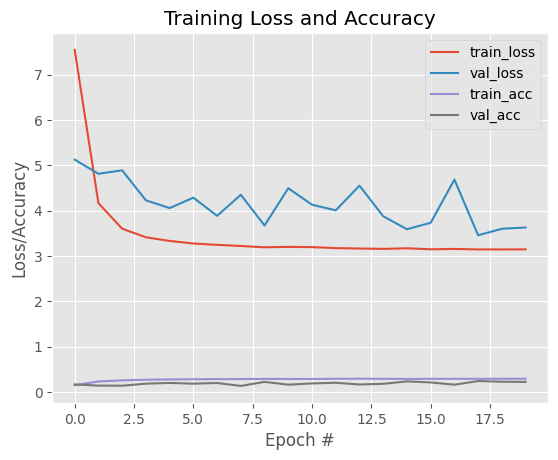

In [ ]:
# ============================================
# Construir el modelo combinando L2 + BatchNorm + Dropout
# ============================================
pre_trained_model = Sequential([
    base_model, # EfficientNetB0 congelada
    Flatten(),
    Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(100, activation='softmax')
])

pre_trained_model.summary()

# Entrenar el modelo
train(x_train_eff, y_train_cat, x_test_eff, y_test_cat, pre_trained_model, BASE_FOLDER)

## **5. DATA AUGMENTATION (empeora el modelo)**

### **5.1 Data augmentation (empeora el modelo)**

La aplicación de técnicas básicas de Data Augmentation (volteo, rotación y traslación) no logró mejorar la capacidad de generalización del modelo. Por el contrario, se observó un empeoramiento en el *accuracy* de validación y un aumento del *overfitting*. Esto puede deberse a que, al mantener el *base model* congelado, las transformaciones de las imágenes no pudieron ser procesadas adecuadamente para extraer características invariantes en la fase convolucional, desestabilizando el aprendizaje en el Top Model.

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_8 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_8               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_8            │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1, 1, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1024)           │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,654,535 (21.57 MB)

 Trainable params: 1,602,404 (6.11 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

...

 Trainable params: 1,602,404 (6.11 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.0775 - loss: 12.3802 - val_accuracy: 0.1617 - val_loss: 7.4259
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.1357 - loss: 6.1653 - val_accuracy: 0.1969 - val_loss: 5.0040
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.1508 - loss: 4.9224 - val_accuracy: 0.1883 - val_loss: 4.4412
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.1592 - loss: 4.5070 - val_accuracy: 0.1677 - val_loss: 4.3799
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.1694 - loss: 4.3009 - val_accuracy: 0.1622 - val_loss: 4.3526
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.1695 - loss: 4.1827 - val_accuracy: 0.1892 - val_loss: 4.0519
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.1734 - loss: 4.1155 - val_accuracy: 0.1657 - val_loss: 4.0959
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step
               precision    recall  f1-score   support

        apple       0.60      0.64      0.62       100
aquarium_fish       0.25      0.01      0.02       100
         baby       0.16      0.26      0.20       100
         bear       0.00      0.00      0.00       100
       beaver       0.00      0.00      0.00       100
          bed       0.13      0.12      0.12       100
          bee       0.22      0.04      0.07       100
       beetle       0.22      0.21      0.22       100
      bicycle       0.28      0.11      0.16       100
       bottle       0.33      0.03      0.06       100
         bowl       0.11      0.29      0.16       100
          boy       0.15      0.07      0.09       100
       bridge       0.26      0.16      0.20       100
          bus       0.19      0.24      0.21       100
    butterfly       0.09      0.20      0.12       100
        camel       0.00      0.00      0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


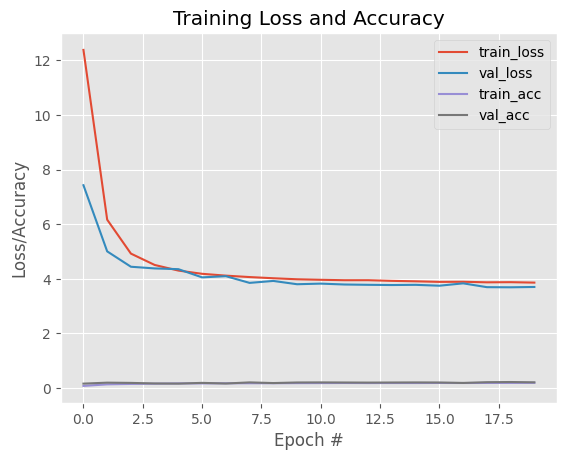

In [ ]:
# Volvemos a instanciar el modelo base congelado para evitar errores de variables no definidas
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False

# ============================================
# Construir modelo completo con Data Augmentation
# ============================================
model = Sequential([
    # Indicamos la forma de entrada
    Input(shape=(32, 32, 3)),

    # Capas de aumento de datos
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.1, 0.1),

    # Modelo base congelado (EfficientNetB0)
    base_model,
    layers.Flatten(),

    # Capas densas con regularización
    layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.BatchNormalization(),
    layers.Dropout(0.75),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(100, activation='softmax')
])

model.summary()

# Entrenamos con la función train, pasando las variables preprocesadas de EfficientNet
train(x_train_eff, y_train_cat, x_test_eff, y_test_cat, model, BASE_FOLDER)

### **5.2 Data augmentation modificando parámetros (empeora aún más)**

Al ajustar a la baja los parámetros de aumento de datos, el modelo siguió sin poder extraer patrones generalizables de forma eficiente, empeorando aún más los resultados y desestabilizando el entrenamiento. Esto refuerza la hipótesis de que, con un *base model* congelado y datos de baja resolución, las técnicas de Data Augmentation pueden introducir ruido o variaciones que el modelo no puede aprender a generalizar correctamente, impactando negativamente en el rendimiento.

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_14 (Sequential)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1, 1, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1024)           │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,654,535 (21.57 MB)

 Trainable params: 1,602,404 (6.11 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

...

 Trainable params: 1,602,404 (6.11 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step - accuracy: 0.0810 - loss: 12.3929 - val_accuracy: 0.1514 - val_loss: 7.4663
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.1381 - loss: 6.1512 - val_accuracy: 0.1816 - val_loss: 5.0213
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.1608 - loss: 4.8801 - val_accuracy: 0.1747 - val_loss: 4.5348
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.1640 - loss: 4.4676 - val_accuracy: 0.1948 - val_loss: 4.1920
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.1719 - loss: 4.2576 - val_accuracy: 0.1808 - val_loss: 4.1938
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.1742 - loss: 4.1599 - val_accuracy: 0.1919 - val_loss: 3.9823
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.1785 - loss: 4.0827 - val_accuracy: 0.1967 - val_loss: 3.9324
Epoch 8/20
313/313 ━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step
               precision    recall  f1-score   support

        apple       0.67      0.59      0.63       100
aquarium_fish       0.07      0.18      0.11       100
         baby       0.17      0.01      0.02       100
         bear       0.04      0.01      0.02       100
       beaver       0.00      0.00      0.00       100
          bed       0.67      0.02      0.04       100
          bee       0.13      0.09      0.11       100
       beetle       0.36      0.14      0.20       100
      bicycle       0.11      0.47      0.18       100
       bottle       0.14      0.22      0.17       100
         bowl       0.13      0.03      0.05       100
          boy       0.13      0.27      0.18       100
       bridge       0.32      0.08      0.13       100
          bus       0.40      0.02      0.04       100
    butterfly       0.07      0.14      0.10       100
        camel       0.00      0.00      0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


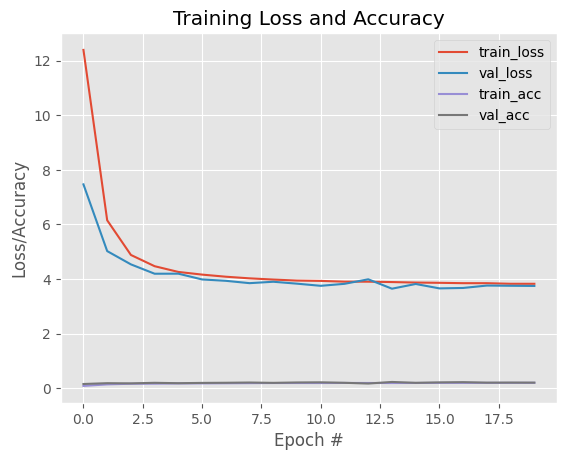

In [ ]:
from tensorflow.keras import layers, regularizers, Input
from tensorflow.keras.models import Sequential

# ============================================
# Definir las capas de aumento de datos
# ============================================
data_augmentation = Sequential([
    Input(shape=(32, 32, 3)),                         # Indicamos la forma de entrada
    layers.RandomFlip("horizontal"),                 # Volteo horizontal aleatorio
    layers.RandomRotation(0.05),                      # Rotación aleatoria (5% de 360°)
    layers.RandomTranslation(0.05, 0.05)              # Traslación horizontal y vertical (5%)
])

# ============================================
# Construir el modelo completo
# ============================================
model = Sequential([
    data_augmentation,                               # Capas de aumento al inicio
    base_model,                                      # EfficientNetB0 congelada
    layers.Flatten(),
    layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.BatchNormalization(),
    layers.Dropout(0.75),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(100, activation='softmax')
])

model.summary()

# Entrenamos con la función train
train(x_train_eff, y_train_cat, x_test_eff, y_test_cat, model, BASE_FOLDER)

## **6. ANÁLISIS DE RESULTADOS DEL EJERCICIO 1**

En la primera estrategia utilizando **Transfer Learning**, se probaron varias arquitecturas preentrenadas en ImageNet, seleccionando finalmente **EfficientNetB0** por su equilibrio y mejor capacidad de generalización inicial.

Al aplicar **Fine Tuning** (descongelando distintos bloques de capas), no se observaron mejoras significativas. Esto se atribuye a la baja resolución espacial de las imágenes del dataset CIFAR-100 (32x32 píxeles), lo que limita la capacidad de las capas convolucionales más profundas para extraer nuevas características complejas sin caer en sobreajuste (*overfitting*).

La modificación de la estructura del **Top Model** (incrementando el número de capas y neuronas hasta topologías de 1024-512-256) tampoco incrementó el *accuracy* de validación, sino que tendió a empeorar el *overfitting* al añadir millones de parámetros entrenables sin suficiente información útil.

De las técnicas de **regularización** probadas, únicamente *Batch Normalization* logró aportar una ligera estabilización al entrenamiento.

Finalmente, la aplicación de **Data Augmentation** afectó negativamente al rendimiento. Al mantener el *base model* congelado, estas transformaciones de las imágenes no pudieron ser procesadas adecuadamente para extraer características invariantes en la fase convolucional, lo que resultó en una desestabilización del aprendizaje en el Top Model y una caída en la precisión.

## ConvNeXtTiny

En esta red, el problema que encontrábamos en el análisis general se debía al sobre ajuste debido a la densidad de estas redes con sus trnasformadores supondremos que la mayor mejoría la veremos al añadir el dropout y regularización, y sobre todo con el data augmentation

## **1. TRANSFER LEARNING**

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ convnext_tiny (Functional)      │ (None, 1, 1, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,265,156 (107.82 MB)

 Trainable params: 445,028 (1.70 MB)

...

 Total params: 28,265,156 (107.82 MB)

 Trainable params: 445,028 (1.70 MB)

 Non-trainable params: 27,820,128 (106.13 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 62ms/step - accuracy: 0.3553 - loss: 2.6811 - val_accuracy: 0.4372 - val_loss: 2.1744
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5245 - loss: 1.7765 - val_accuracy: 0.4850 - val_loss: 1.9841
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.5968 - loss: 1.4682 - val_accuracy: 0.4951 - val_loss: 1.9362
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6532 - loss: 1.2555 - val_accuracy: 0.5018 - val_loss: 1.9161
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.6998 - loss: 1.0850 - val_accuracy: 0.5027 - val_loss: 1.9216
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7423 - loss: 0.9412 - val_accuracy: 0.5043 - val_loss: 1.9282
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.7863 - loss: 0.8071 - val_accuracy: 0.5024 - val_loss: 1.9642
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step
               precision    recall  f1-score   support

        apple       0.72      0.81      0.76       100
aquarium_fish       0.53      0.52      0.53       100
         baby       0.31      0.45      0.36       100
         bear       0.34      0.23      0.28       100
       beaver       0.31      0.33      0.32       100
          bed       0.51      0.44      0.47       100
          bee       0.46      0.61      0.53       100
       beetle       0.53      0.48      0.51       100
      bicycle       0.61      0.58      0.59       100
       bottle       0.74      0.65      0.69       100
         bowl       0.39      0.35      0.37       100
          boy       0.33      0.32      0.33       100
       bridge       0.63      0.62      0.63       100
          bus       0.42      0.35      0.38       100
    butterfly       0.45      0.41      0.43       100
        camel       0.38      0.51      0.43   

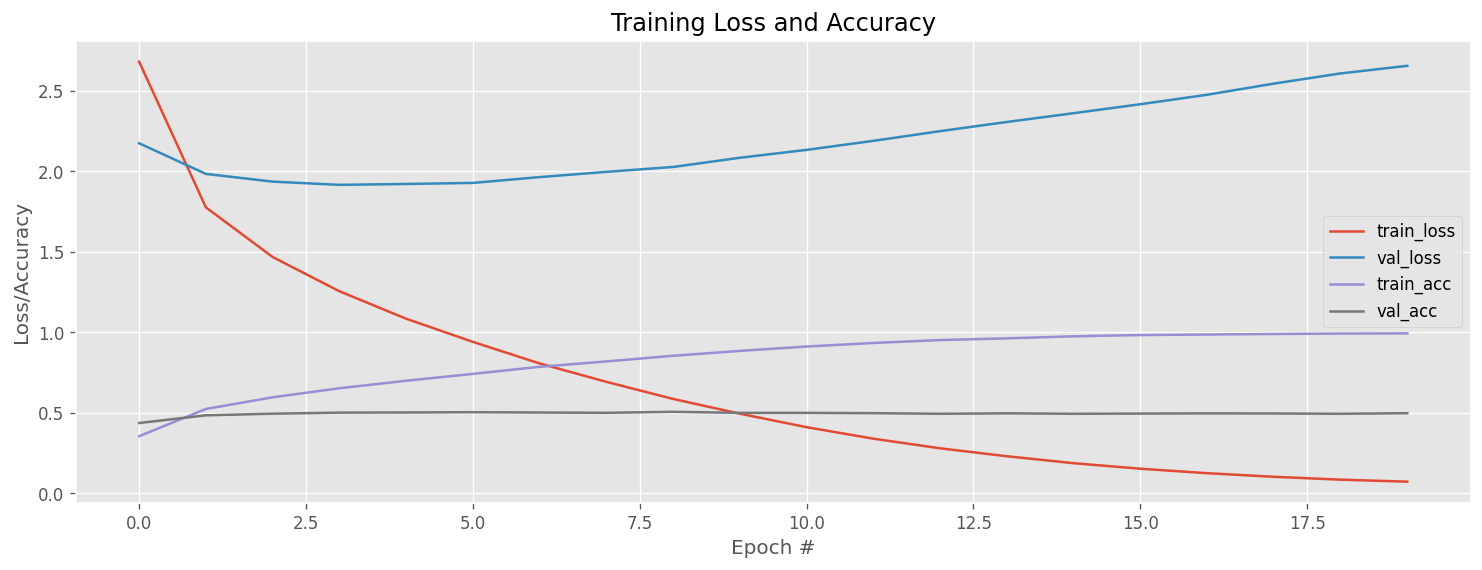

In [ ]:
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras.applications.convnext import preprocess_input
from tensorflow.keras.utils import to_categorical


# 1. Preprocesamiento específico para ConvNeXtTiny
# Importante: Si tus datos están en rango [0, 1], asegúrate de que preprocess_input
# los reciba en el formato que espera (normalmente escala y normaliza según ImageNet)
x_train_cn = preprocess_input(np.copy(x_train))
x_test_cn = preprocess_input(np.copy(x_test))

# 2. Etiquetas a One-Hot
y_train_cat = to_categorical(y_train, 100)
y_test_cat = to_categorical(y_test, 100)

# 3. Definir el modelo base (ConvNeXtTiny)
# Usamos include_top=False para quitar la capa de 1000 clases de ImageNet
base_model = ConvNeXtTiny(weights='imagenet',
                            include_top=False,
                            input_shape=(32, 32, 3))

# CONGELAMOS todas las capas convolucionales
base_model.trainable = False

# 4. Construir el Top Model (la parte densa)
pre_trained_model = Sequential()
pre_trained_model.add(base_model)
pre_trained_model.add(layers.Flatten())
pre_trained_model.add(layers.Dense(512, activation='relu'))
pre_trained_model.add(layers.Dense(100, activation='softmax'))

# Visualizar la estructura
pre_trained_model.summary()

# 5. Entrenamiento
# Usamos las versiones preprocesadas (_cn) y las etiquetas categóricas (_cat)
train(x_train_cn, y_train_cat, x_test_cn, y_test_cat, pre_trained_model, BASE_FOLDER)

## **2. FINE TUNING** (con mejoría)

In [ ]:
# Contar el número total de capas en el modelo base (ConvNeXtTiny)
num_capas_base = len(base_model.layers)
print(f"Número de capas en el modelo base (ConvNeXtTiny): {num_capas_base}")

# Contar el número total de capas en el modelo completo (Base + Top Model)
num_capas_total = len(model.layers)
print(f"Número de capas en el modelo completo: {num_capas_total}")

# Ver cuántas de esas capas son entrenables actualmente
capas_entrenables = sum([1 for layer in model.layers if layer.trainable])
print(f"Número de capas entrenables: {capas_entrenables}")

Número de capas en el modelo base (ConvNeXtTiny): 133
Número de capas en el modelo completo: 241
Número de capas entrenables: 41


### **2.1. Congelamos 100/133 capas**

[INFO]: Capas totales del base_model: 133
[INFO]: Capas congeladas: 100
[INFO]: Capas entrenables en base_model: 33


Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_pres… │ (None, 32, 32, 3) │          0 │ input_layer_16[0… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stem  │ (None, 8, 8, 96)  │      4,896 │ convnext_tiny_pr… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 96)  │      4,800 │ convnext_tiny_st… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 96)  │        192 │ convnext_tiny_st… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 384) │     37,248 │ convnext_tiny_st… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 384) │          0 │ convnext_tiny_st… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 96)  │     36,960 │ convnext_tiny_st… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 96)  │         96 │ convnext_tiny_st… │
│ (LayerScale)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 96)  │          0 │ convnext_tiny_st… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_36 (Add)        │ (None, 8, 8, 96)  │          0 │ convnext_tiny_st… │
│                     │                   │            │ convnext_tiny_st… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 96)  │      4,800 │ add_36[0][0]      │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 96)  │        192 │ convnext_tiny_st… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 384) │     37,248 │ convnext_tiny_st… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 384) │          0 │ convnext_tiny_st… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 96)  │     36,960 │ convnext_tiny_st… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 96)  │         96 │ convnext_tiny_st

 Total params: 28,265,156 (107.82 MB)

 Trainable params: 17,709,668 (67.56 MB)

 Non-trainable params: 10,555,488 (40.27 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 57s 109ms/step - accuracy: 0.3229 - loss: 2.8487 - val_accuracy: 0.4774 - val_loss: 1.9438
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.5618 - loss: 1.5852 - val_accuracy: 0.5372 - val_loss: 1.6872
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.6710 - loss: 1.1694 - val_accuracy: 0.5628 - val_loss: 1.5974
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.7683 - loss: 0.8372 - val_accuracy: 0.5754 - val_loss: 1.5792
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.8633 - loss: 0.5471 - val_accuracy: 0.5802 - val_loss: 1.6076
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.9352 - loss: 0.3148 - val_accuracy: 0.5791 - val_loss: 1.6674
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.9761 - loss: 0.1595 - val_accuracy: 0.5820 - val_loss: 1.7301
Epoch 8/20
313/313 ━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step
               precision    recall  f1-score   support

        apple       0.75      0.77      0.76       100
aquarium_fish       0.74      0.65      0.69       100
         baby       0.45      0.42      0.43       100
         bear       0.35      0.37      0.36       100
       beaver       0.47      0.41      0.44       100
          bed       0.61      0.58      0.59       100
          bee       0.57      0.54      0.55       100
       beetle       0.63      0.64      0.63       100
      bicycle       0.76      0.71      0.74       100
       bottle       0.73      0.76      0.75       100
         bowl       0.47      0.33      0.39       100
          boy       0.39      0.33      0.36       100
       bridge       0.70      0.76      0.73       100
          bus       0.56      0.49      0.52       100
    butterfly       0.49      0.48      0.49       100
        camel       0.53      0.51      0.52    

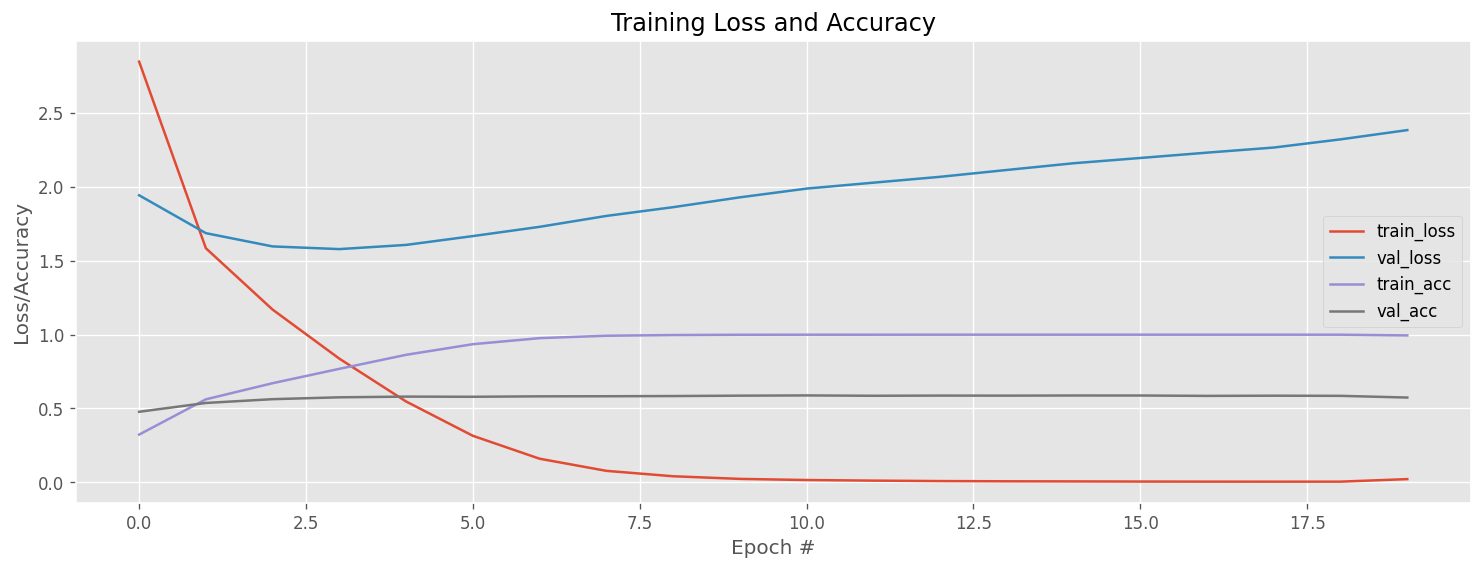

In [ ]:
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense

# 1. Cargamos el modelo base
base_model = ConvNeXtTiny(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# 2. Congelamos exactamente 100 capas
NUM_CONGELADAS = 100
for layer in base_model.layers[:NUM_CONGELADAS]:
    layer.trainable = False
for layer in base_model.layers[NUM_CONGELADAS:]:
    layer.trainable = True

# 3. Construimos el modelo completo
last_output = base_model.layers[-1].output
x = Flatten()(last_output)
x = Dense(512, activation='relu', name='fc1')(x)
x = Dense(100, activation='softmax', name='predictions')(x)

model = Model(inputs=base_model.input, outputs=x)

# 4. Entrenamos el modelo con un learning rate bajo (típico en fine-tuning)
print(f"[INFO]: Capas totales del base_model: {len(base_model.layers)}")
print(f"[INFO]: Capas congeladas: {NUM_CONGELADAS}")
print(f"[INFO]: Capas entrenables en base_model: {len(base_model.layers) - NUM_CONGELADAS}")

train(x_train_cn, y_train_cat, x_test_cn, y_test_cat, model, BASE_FOLDER, learn_rate=0.0001)

### **2.1. Congelamos 50/133 capas**

[INFO]: Capas totales del base_model: 133
[INFO]: Capas congeladas: 50
[INFO]: Capas entrenables en base_model: 83


Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_21      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_pres… │ (None, 32, 32, 3) │          0 │ input_layer_21[0… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stem  │ (None, 8, 8, 96)  │      4,896 │ convnext_tiny_pr… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 96)  │      4,800 │ convnext_tiny_st… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 96)  │        192 │ convnext_tiny_st… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 384) │     37,248 │ convnext_tiny_st… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 384) │          0 │ convnext_tiny_st… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 96)  │     36,960 │ convnext_tiny_st… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 96)  │         96 │ convnext_tiny_st… │
│ (LayerScale)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 96)  │          0 │ convnext_tiny_st… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_54 (Add)        │ (None, 8, 8, 96)  │          0 │ convnext_tiny_st… │
│                     │                   │            │ convnext_tiny_st… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 96)  │      4,800 │ add_54[0][0]      │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 96)  │        192 │ convnext_tiny_st… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 384) │     37,248 │ convnext_tiny_st… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 384) │          0 │ convnext_tiny_st… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 96)  │     36,960 │ convnext_tiny_st… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 8, 8, 96)  │         96 │ convnext_tiny_st

 Total params: 28,265,156 (107.82 MB)

 Trainable params: 26,123,108 (99.65 MB)

 Non-trainable params: 2,142,048 (8.17 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 202ms/step - accuracy: 0.3773 - loss: 2.5621 - val_accuracy: 0.5451 - val_loss: 1.6395
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 142ms/step - accuracy: 0.6406 - loss: 1.2612 - val_accuracy: 0.6093 - val_loss: 1.4023
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 141ms/step - accuracy: 0.7656 - loss: 0.8134 - val_accuracy: 0.6400 - val_loss: 1.3245
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 143ms/step - accuracy: 0.8728 - loss: 0.4734 - val_accuracy: 0.6406 - val_loss: 1.3526
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 140ms/step - accuracy: 0.9505 - loss: 0.2296 - val_accuracy: 0.6480 - val_loss: 1.4015
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 142ms/step - accuracy: 0.9862 - loss: 0.0943 - val_accuracy: 0.6474 - val_loss: 1.4656
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 146ms/step - accuracy: 0.9963 - loss: 0.0397 - val_accuracy: 0.6488 - val_loss: 1.5348
Epoch 8/20
313/313 ━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step
               precision    recall  f1-score   support

        apple       0.79      0.86      0.82       100
aquarium_fish       0.72      0.76      0.74       100
         baby       0.51      0.56      0.54       100
         bear       0.55      0.45      0.49       100
       beaver       0.45      0.52      0.48       100
          bed       0.66      0.68      0.67       100
          bee       0.72      0.73      0.72       100
       beetle       0.66      0.59      0.62       100
      bicycle       0.80      0.81      0.81       100
       bottle       0.76      0.81      0.79       100
         bowl       0.54      0.59      0.56       100
          boy       0.40      0.40      0.40       100
       bridge       0.71      0.78      0.74       100
          bus       0.59      0.52      0.55       100
    butterfly       0.64      0.65      0.65       100
        camel       0.60      0.61      0.60    

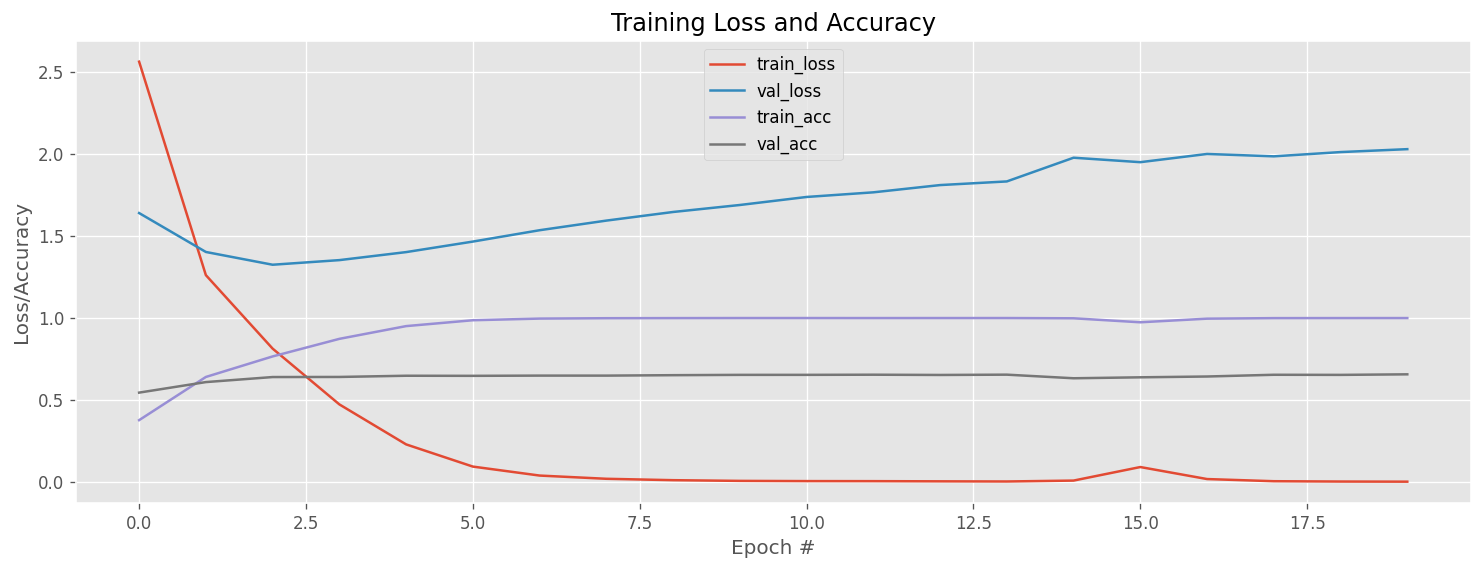

In [ ]:
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense

# 1. Cargamos el modelo base
base_model = ConvNeXtTiny(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# 2. Congelamos exactamente 50 capas
NUM_CONGELADAS = 50
for layer in base_model.layers[:NUM_CONGELADAS]:
    layer.trainable = False
for layer in base_model.layers[NUM_CONGELADAS:]:
    layer.trainable = True

# 3. Construimos el modelo completo
last_output = base_model.layers[-1].output
x = Flatten()(last_output)
x = Dense(512, activation='relu', name='fc1')(x)
x = Dense(100, activation='softmax', name='predictions')(x)

model = Model(inputs=base_model.input, outputs=x)

# 4. Entrenamos el modelo con un learning rate bajo (típico en fine-tuning)
print(f"[INFO]: Capas totales del base_model: {len(base_model.layers)}")
print(f"[INFO]: Capas congeladas: {NUM_CONGELADAS}")
print(f"[INFO]: Capas entrenables en base_model: {len(base_model.layers) - NUM_CONGELADAS}")

train(x_train_cn, y_train_cat, x_test_cn, y_test_cat, model, BASE_FOLDER, learn_rate=0.0001)

## **3. AJUSTE ESTRUCTURA TOP MODEL** (sin mejoría)

Ajuste con GlobalAveragePooling2D

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ convnext_tiny (Functional)      │ (None, 1, 1, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        76,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,897,028 (106.42 MB)

 Trainable params: 76,900 (300.39 KB)

 Non-trainable params: 27,820,128 (106.13 MB)

...

 Total params: 27,897,028 (106.42 MB)

 Trainable params: 76,900 (300.39 KB)

 Non-trainable params: 27,820,128 (106.13 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 56ms/step - accuracy: 0.2668 - loss: 3.2131 - val_accuracy: 0.3850 - val_loss: 2.4588
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4445 - loss: 2.1649 - val_accuracy: 0.4433 - val_loss: 2.1594
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5018 - loss: 1.8880 - val_accuracy: 0.4675 - val_loss: 2.0379
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5355 - loss: 1.7291 - val_accuracy: 0.4828 - val_loss: 1.9666
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5616 - loss: 1.6209 - val_accuracy: 0.4926 - val_loss: 1.9243
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5814 - loss: 1.5377 - val_accuracy: 0.4985 - val_loss: 1.8948
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5988 - loss: 1.4727 - val_accuracy: 0.5033 - val_loss: 1.8760
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step
               precision    recall  f1-score   support

        apple       0.67      0.80      0.73       100
aquarium_fish       0.53      0.59      0.56       100
         baby       0.41      0.50      0.45       100
         bear       0.35      0.29      0.32       100
       beaver       0.30      0.25      0.27       100
          bed       0.52      0.43      0.47       100
          bee       0.55      0.54      0.55       100
       beetle       0.55      0.53      0.54       100
      bicycle       0.68      0.67      0.67       100
       bottle       0.66      0.63      0.64       100
         bowl       0.42      0.39      0.40       100
          boy       0.32      0.30      0.31       100
       bridge       0.73      0.66      0.69       100
          bus       0.55      0.41      0.47       100
    butterfly       0.42      0.40      0.41       100
        camel       0.48      0.49      0.48    

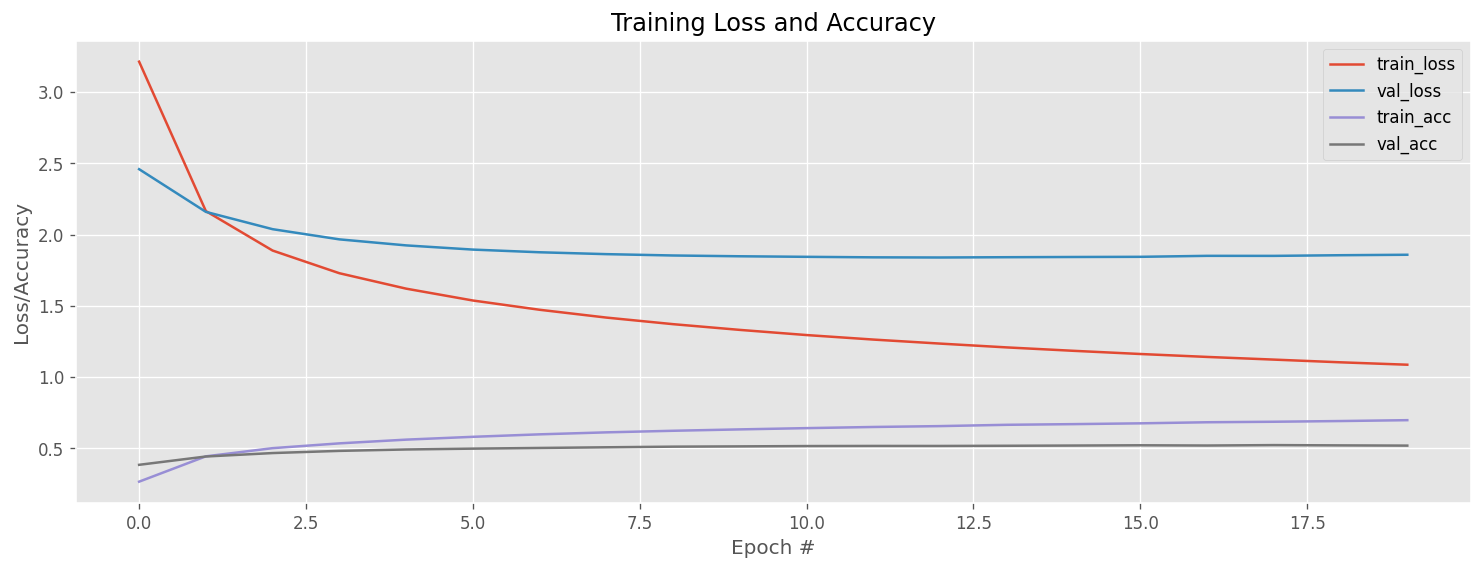

In [ ]:
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras.models import Model
from tensorflow.keras.layers import MaxPooling2D, Dense

# 1. Cargamos el modelo base congelado (Transfer Learning)
base_model = ConvNeXtTiny(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False

# 2. Construir modelo completo (Primer intento: 256 neuronas)
pre_trained_model = Sequential([
    base_model,
    # Flatten(),
    # Dense(256, activation='relu'),
    layers.GlobalAveragePooling2D(),
    Dense(100, activation='softmax')  # 100 clases
])
pre_trained_model.summary()

# 3. Entrenar modelo
train(x_train_cn, y_train_cat, x_test_cn, y_test_cat, pre_trained_model, BASE_FOLDER)

## **4. AJUSTE PARÁMETROS DE REGULARIZACIÓN** (mejoría)

### **4.1. Weight regularization L2 (sin mejoría)**


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ convnext_tiny (Functional)      │ (None, 1, 1, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        76,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,897,028 (106.42 MB)

 Trainable params: 76,900 (300.39 KB)

 Non-trainable params: 27,820,128 (106.13 MB)

...

 Total params: 27,897,028 (106.42 MB)

 Trainable params: 76,900 (300.39 KB)

 Non-trainable params: 27,820,128 (106.13 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.2711 - loss: 13.0385 - val_accuracy: 0.3844 - val_loss: 12.2867
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.4444 - loss: 11.9911 - val_accuracy: 0.4462 - val_loss: 11.9834
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5032 - loss: 11.7135 - val_accuracy: 0.4692 - val_loss: 11.8577
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5364 - loss: 11.5556 - val_accuracy: 0.4872 - val_loss: 11.7888
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5613 - loss: 11.4459 - val_accuracy: 0.4951 - val_loss: 11.7461
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5802 - loss: 11.3625 - val_accuracy: 0.5024 - val_loss: 11.7205
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5974 - loss: 11.2967 - val_accuracy: 0.5041 - val_loss: 11.6990
Epoch 8/20
313/313 ━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step
               precision    recall  f1-score   support

        apple       0.78      0.80      0.79       100
aquarium_fish       0.58      0.55      0.56       100
         baby       0.44      0.46      0.45       100
         bear       0.38      0.29      0.33       100
       beaver       0.32      0.28      0.30       100
          bed       0.50      0.41      0.45       100
          bee       0.62      0.51      0.56       100
       beetle       0.52      0.53      0.52       100
      bicycle       0.60      0.67      0.63       100
       bottle       0.65      0.62      0.63       100
         bowl       0.43      0.38      0.40       100
          boy       0.34      0.29      0.31       100
       bridge       0.64      0.71      0.67       100
          bus       0.45      0.48      0.46       100
    butterfly       0.41      0.41      0.41       100
        camel       0.47      0.53      0.50    

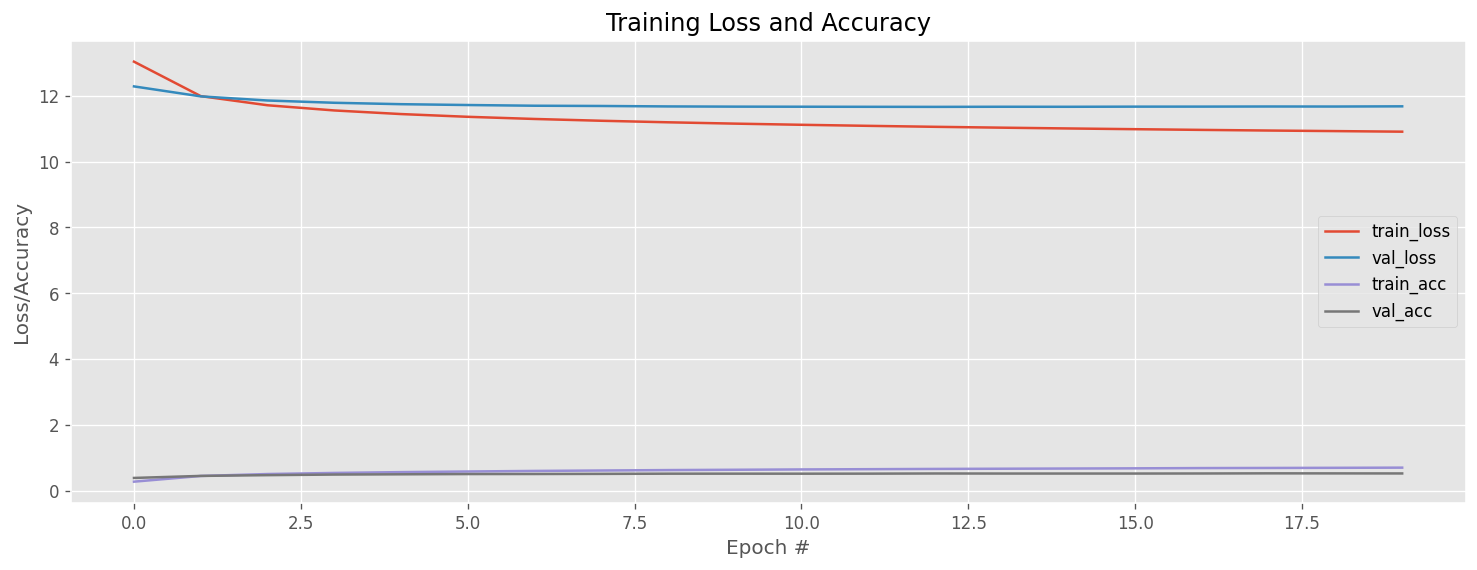

In [ ]:
from tensorflow.keras import regularizers

# ============================================
# Construir modelo completo solo con regularización L2
# ============================================
pre_trained_model = Sequential([
    base_model,
    # Flatten(),
    # Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01)),  # L2 en pesos
    layers.GlobalAveragePooling2D(activity_regularizer=regularizers.l2(1e-4)),
    Dense(100, activation='softmax')  # Sin regularización en la capa de salida
])

pre_trained_model.summary()

# Entrenar el modelo
train(x_train_cn, y_train_cat, x_test_cn, y_test_cat, pre_trained_model, BASE_FOLDER)

### **4.2. Dropout (sin mejoría)**


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ convnext_tiny (Functional)      │ (None, 1, 1, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        76,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,897,028 (106.42 MB)

 Trainable params: 76,900 (300.39 KB)

 Non-trainable params: 27,820,128 (106.13 MB)

...

 Total params: 27,897,028 (106.42 MB)

 Trainable params: 76,900 (300.39 KB)

 Non-trainable params: 27,820,128 (106.13 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.2393 - loss: 3.4376 - val_accuracy: 0.3768 - val_loss: 2.5026
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4143 - loss: 2.3183 - val_accuracy: 0.4404 - val_loss: 2.1808
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4710 - loss: 2.0297 - val_accuracy: 0.4700 - val_loss: 2.0433
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5033 - loss: 1.8749 - val_accuracy: 0.4822 - val_loss: 1.9736
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5228 - loss: 1.7632 - val_accuracy: 0.4927 - val_loss: 1.9239
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5420 - loss: 1.6900 - val_accuracy: 0.4991 - val_loss: 1.8931
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5546 - loss: 1.6300 - val_accuracy: 0.5044 - val_loss: 1.8684
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step
               precision    recall  f1-score   support

        apple       0.71      0.79      0.75       100
aquarium_fish       0.52      0.62      0.56       100
         baby       0.41      0.48      0.44       100
         bear       0.41      0.33      0.37       100
       beaver       0.40      0.36      0.38       100
          bed       0.46      0.41      0.43       100
          bee       0.58      0.55      0.56       100
       beetle       0.50      0.55      0.52       100
      bicycle       0.65      0.66      0.65       100
       bottle       0.63      0.64      0.63       100
         bowl       0.42      0.40      0.41       100
          boy       0.34      0.28      0.31       100
       bridge       0.60      0.66      0.63       100
          bus       0.53      0.42      0.47       100
    butterfly       0.40      0.40      0.40       100
        camel       0.50      0.51      0.50    

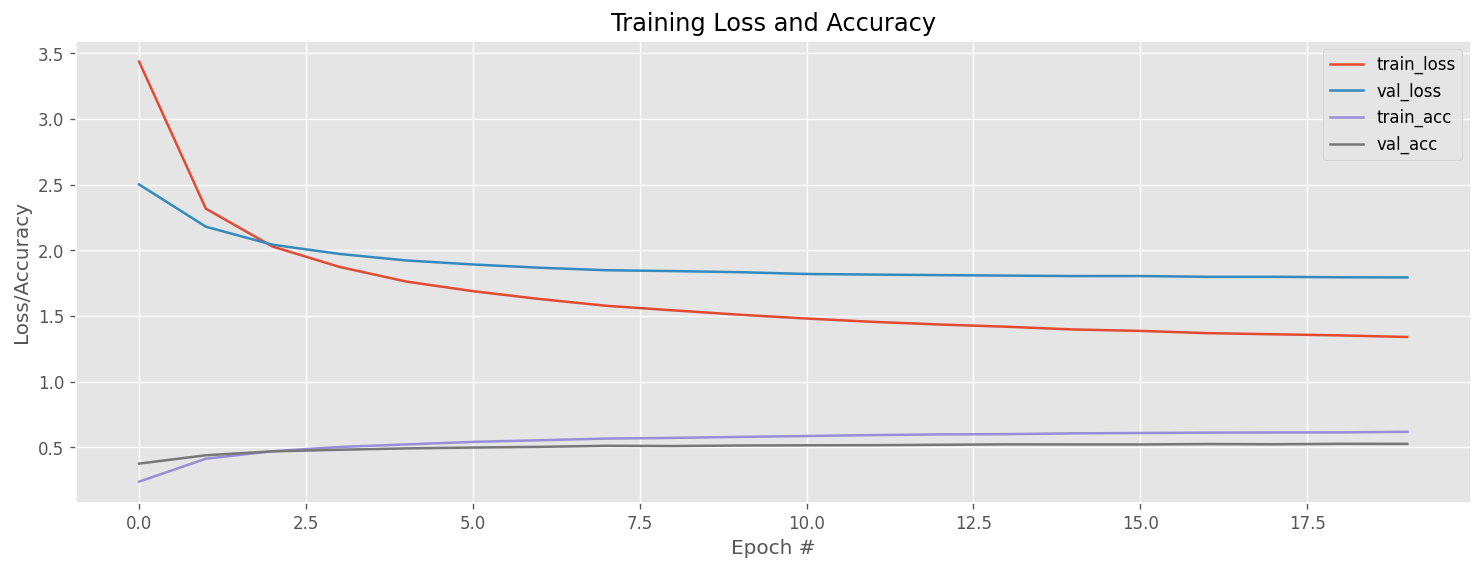

In [ ]:
from tensorflow.keras.layers import Dropout

# ============================================
# Construir modelo completo con Dropout
# ============================================
pre_trained_model = Sequential([
    base_model,
    # Flatten(),
    # Dense(256, activation='relu'),
    layers.GlobalAveragePooling2D(),
    Dropout(0.2), # Apaga el 20% de las neuronas durante el entrenamiento
    Dense(100, activation='softmax')
])

pre_trained_model.summary()

# Entrenar el modelo
train(x_train_cn, y_train_cat, x_test_cn, y_test_cat, pre_trained_model, BASE_FOLDER)

### **4.3. Batch normalization (mejoría)**


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ convnext_tiny (Functional)      │ (None, 1, 1, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 768)            │         3,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        76,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,900,100 (106.43 MB)

 Trainable params: 78,436 (306.39 KB)

 Non-trainable params: 27,821,664 (106.13 MB)

...

 Total params: 27,900,100 (106.43 MB)

 Trainable params: 78,436 (306.39 KB)

 Non-trainable params: 27,821,664 (106.13 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 53ms/step - accuracy: 0.2985 - loss: 3.0356 - val_accuracy: 0.4203 - val_loss: 2.3159
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4699 - loss: 2.0424 - val_accuracy: 0.4690 - val_loss: 2.0517
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5263 - loss: 1.7854 - val_accuracy: 0.4937 - val_loss: 1.9484
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5584 - loss: 1.6316 - val_accuracy: 0.5038 - val_loss: 1.8950
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5837 - loss: 1.5226 - val_accuracy: 0.5138 - val_loss: 1.8621
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6045 - loss: 1.4370 - val_accuracy: 0.5161 - val_loss: 1.8427
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6188 - loss: 1.3688 - val_accuracy: 0.5200 - val_loss: 1.8318
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step
               precision    recall  f1-score   support

        apple       0.75      0.79      0.77       100
aquarium_fish       0.62      0.59      0.61       100
         baby       0.40      0.54      0.46       100
         bear       0.37      0.32      0.34       100
       beaver       0.34      0.35      0.35       100
          bed       0.51      0.49      0.50       100
          bee       0.55      0.57      0.56       100
       beetle       0.49      0.52      0.50       100
      bicycle       0.65      0.64      0.65       100
       bottle       0.64      0.65      0.64       100
         bowl       0.42      0.37      0.39       100
          boy       0.37      0.31      0.34       100
       bridge       0.63      0.71      0.67       100
          bus       0.45      0.44      0.44       100
    butterfly       0.44      0.41      0.42       100
        camel       0.46      0.56      0.50   

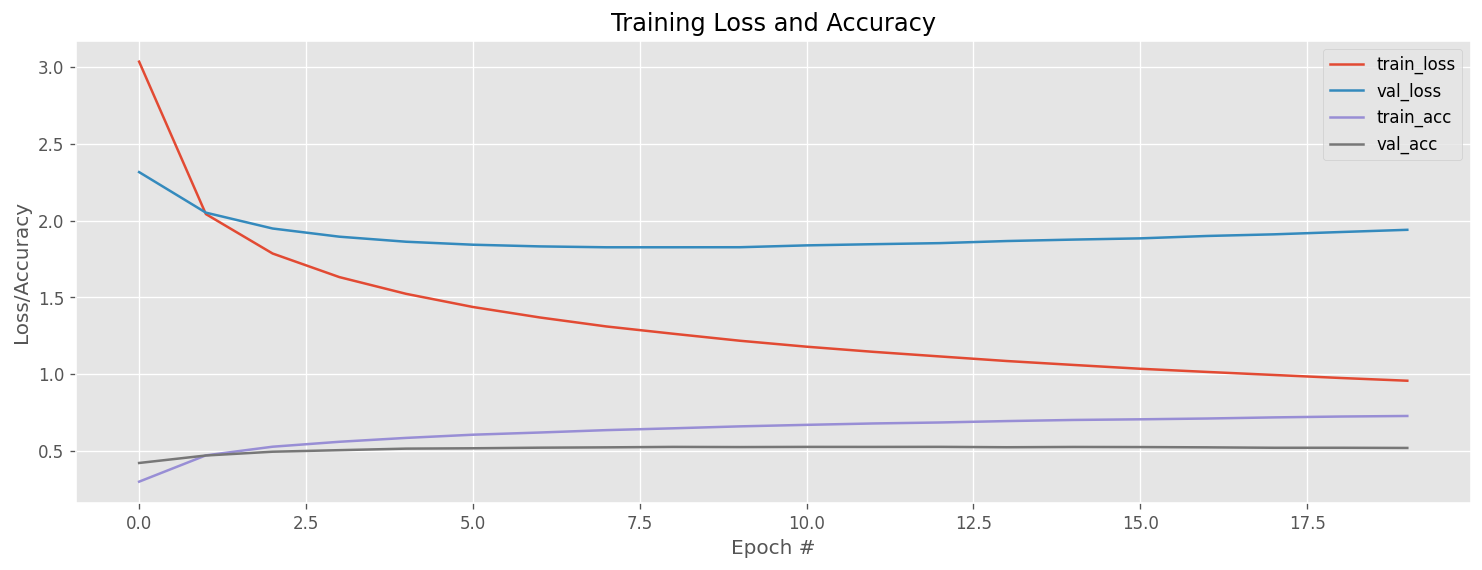

In [ ]:
from tensorflow.keras.layers import BatchNormalization

# ============================================
# Construir modelo completo con BatchNormalization
# ============================================
pre_trained_model = Sequential([
    base_model,
    # Flatten(),
    # Dense(256, activation='relu'),
    layers.GlobalAveragePooling2D(),
    BatchNormalization(),                # Normalización
    Dense(100, activation='softmax')     # 100 clases
])

pre_trained_model.summary()

# Entrenar el modelo
train(x_train_cn, y_train_cat, x_test_cn, y_test_cat, pre_trained_model, BASE_FOLDER)

### **4.4. Combinación de las 3 técnicas de regularización (sin mejoría)**

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ convnext_tiny (Functional)      │ (None, 1, 1, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 768)            │         3,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        76,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,900,100 (106.43 MB)

 Trainable params: 78,436 (306.39 KB)

 Non-trainable params: 27,821,664 (106.13 MB)

...

 Total params: 27,900,100 (106.43 MB)

 Trainable params: 78,436 (306.39 KB)

 Non-trainable params: 27,821,664 (106.13 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 55ms/step - accuracy: 0.2677 - loss: 13.0732 - val_accuracy: 0.4006 - val_loss: 12.2014
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4367 - loss: 12.0301 - val_accuracy: 0.4571 - val_loss: 11.9147
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.4864 - loss: 11.7751 - val_accuracy: 0.4852 - val_loss: 11.7970
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5195 - loss: 11.6190 - val_accuracy: 0.4943 - val_loss: 11.7303
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5362 - loss: 11.5248 - val_accuracy: 0.5077 - val_loss: 11.6920
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5566 - loss: 11.4427 - val_accuracy: 0.5128 - val_loss: 11.6668
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5691 - loss: 11.3874 - val_accuracy: 0.5179 - val_loss: 11.6437
Epoch 8/20
313/313 

[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step
               precision    recall  f1-score   support

        apple       0.72      0.77      0.74       100
aquarium_fish       0.56      0.62      0.59       100
         baby       0.46      0.51      0.49       100
         bear       0.43      0.32      0.37       100
       beaver       0.36      0.31      0.33       100
          bed       0.52      0.44      0.48       100
          bee       0.62      0.57      0.59       100
       beetle       0.50      0.57      0.53       100
      bicycle       0.70      0.64      0.67       100
       bottle       0.63      0.66      0.65       100
         bowl       0.46      0.38      0.42       100
          boy       0.31      0.33      0.32       100
       bridge       0.60      0.73      0.66       100
          bus       0.49      0.45      0.47       100
    butterfly       0.42      0.36      0.39       100
        camel       0.49      0.52      0.50    

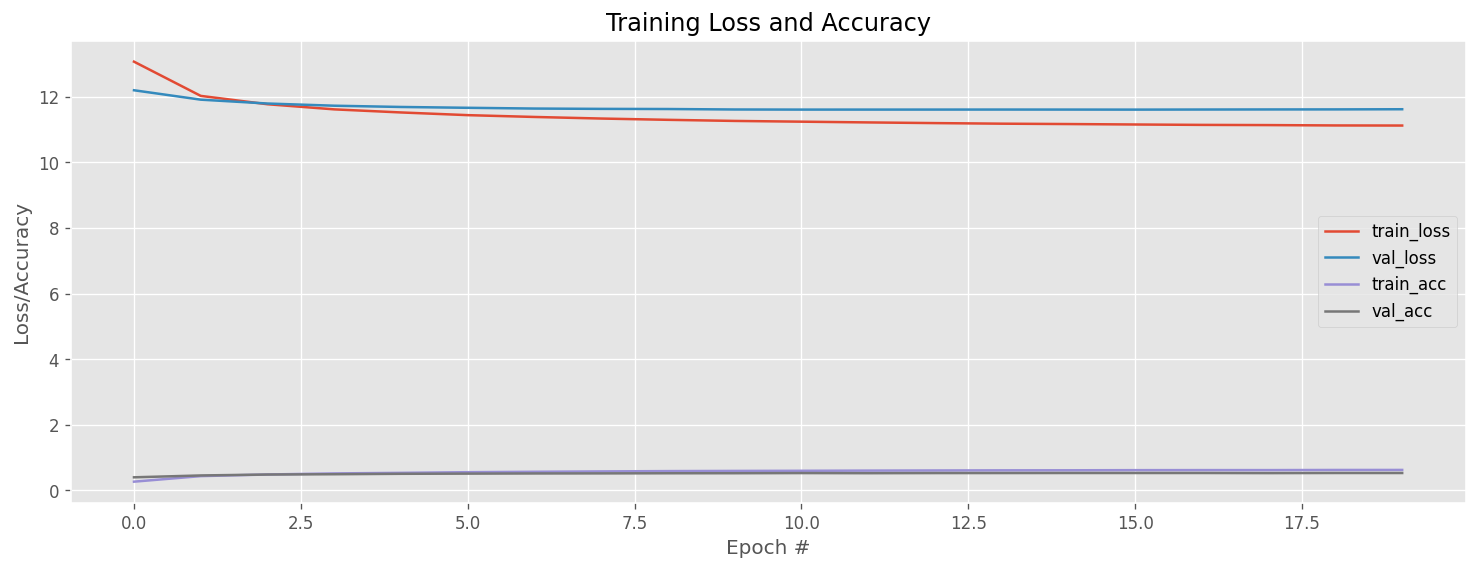

In [ ]:
# ============================================
# Construir el modelo combinando L2 + BatchNorm + Dropout
# ============================================
pre_trained_model = Sequential([
    base_model,
    # Flatten(),
    # Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01)),  # L2 en pesos
    layers.GlobalAveragePooling2D(activity_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(100, activation='softmax')
])

pre_trained_model.summary()

# Entrenar el modelo
train(x_train_cn, y_train_cat, x_test_cn, y_test_cat, pre_trained_model, BASE_FOLDER)

## **5. DATA AUGMENTATION**

In [ ]:
# Volvemos a instanciar el modelo base congelado para evitar errores de variables no definidas
base_model = ConvNeXtTiny(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False

# ============================================
# Construir modelo completo con Data Augmentation
# ============================================
model = Sequential([
    # Indicamos la forma de entrada
    Input(shape=(32, 32, 3)),

    # Capas de aumento de datos
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.1, 0.1),

    # Modelo base congelado (ConvNeXtTiny)
    base_model,

    # Capas densas con regularización
    layers.GlobalAveragePooling2D(activity_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(100, activation='softmax')
])

model.summary()

# Entrenamos con la función train, pasando las variables preprocesadas de EfficientNet
train(x_train_cn, y_train_cat, x_test_cn, y_test_cat, model, BASE_FOLDER)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_1            │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 1, 1, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 768)            │         3,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │        76,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,900,100 (106.43 MB)

 Trainable params: 78,436 (306.39 KB)

 Non-trainable params: 27,821,664 (106.13 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_1            │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 1, 1, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 768)            │         3,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │        76,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,900,100 (106.43 MB)

 Trainable params: 78,436 (306.39 KB)

 Non-trainable params: 27,821,664 (106.13 MB)

[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 90ms/step - accuracy: 0.2054 - loss: 13.4222 - val_accuracy: 0.3781 - val_loss: 12.3442
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.3433 - loss: 12.4731 - val_accuracy: 0.4316 - val_loss: 12.0367
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.3907 - loss: 12.2152 - val_accuracy: 0.4605 - val_loss: 11.9024
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.4154 - loss: 12.0893 - val_accuracy: 0.4757 - val_loss: 11.8289
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.4313 - loss: 11.9983 - val_accuracy: 0.4826 - val_loss: 11.7860
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.4464 - loss: 11.9266 - val_accuracy: 0.4885 - val_loss: 11.7495
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.4557 - loss: 11.8857 - val_accuracy: 0.4928 - val_loss: 11.7228
Epoch 8/20
313/

## **6. ANÁLISIS DE RESULTADOS**

Tras aplicar Transfer Learning con la arquitectura ConvNeXtTiny (pre-entrenada en ImageNet) sobre el dataset CIFAR-100, se extraen las siguientes observaciones clave:

- Desempeño en Entrenamiento: El modelo demostró una capacidad de aprendizaje superior, alcanzando una precisión (accuracy) en el conjunto de entrenamiento de aproximadamente 61.90% y una pérdida (loss) de 1.34 tras 20 épocas.
- Capacidad de Generalización: Se observa una brecha moderada de rendimiento frente a la validación, logrando un val_accuracy del 52.70%. Aunque presenta mejores métricas que los modelos entrenados desde cero, existe un margen de overfitting que podría mitigarse con técnicas de regularización adicionales.
- Efectividad por Clases: El análisis del reporte de clasificación muestra resultados sobresalientes en categorías con rasgos distintivos como keyboard (0.91 precisión) o apple (0.71 precisión), mientras que encuentra dificultades en clases con alta similitud visual o baja resolución.
- Conclusión de la Arquitectura: ConvNeXtTiny se posiciona como una de las opciones más robustas dentro de la Estrategia 1. A pesar de trabajar con imágenes de baja resolución (32x32), su diseño de convoluciones modernas permite una extracción de características más eficiente que arquitecturas clásicas como VGG16.

# EJERCICIO 2

## **ESTRATEGIA 2: Entrenar desde cero (From Scratch)**

En esta segunda parte de la actividad, diseñaremos una **Red Neuronal Convolucional (CNN)** desde cero. Para ello, construiremos una arquitectura basada en bloques convolucionales con las siguientes decisiones de diseño empíricas:

1. **Capas Convolucionales:** Utilizaremos filtros de 3x3 para extraer características espaciales de las imágenes de 32x32. Empezaremos con 32 filtros y aumentaremos a 64 y 128 a medida que profundizamos en la red.
2. **MaxPooling:** Reducirá progresivamente las dimensiones espaciales para quedarse con las características más importantes y reducir la carga computacional.
3. **Batch Normalization:** Añadido después de las activaciones para acelerar la convergencia y estabilizar la red.
4. **Dropout:** Utilizaremos un dropout progresivo (0.25 en capas convolucionales y 0.5 en las densas) para obligar a la red a no depender de neuronas específicas, mitigando así el *overfitting*.

Para esta red, normalizaremos los datos de entrada al rango `[0, 1]` dividiendo por 255.0.

### Bloques clásicos con reducción de dimensionalidad (Diseño inicial)

*Esta sección presenta la arquitectura inicial de la red CNN entrenada desde cero, sirviendo como línea base para las futuras comparaciones.*

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 604,804 (2.31 MB)

 Trainable params: 602,884 (2.30 MB)

 Non-trainable params: 1,920 (7.50 KB)

[INFO]: Compilando el modelo desde cero...
[INFO]: Entrenando el modelo...
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 43ms/step - accuracy: 0.0787 - loss: 4.4186 - val_accuracy: 0.0144 - val_loss: 6.4284
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.1666 - loss: 3.5836 - val_accuracy: 0.2218 - val_loss: 3.2396
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.2384 - loss: 3.1251 - val_accuracy: 0.2447 - val_loss: 3.1440
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.2891 - loss: 2.8091 - val_accuracy: 0.3173 - val_loss: 2.6979
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3370 - loss: 2.5756 - val_accuracy: 0.3752 - val_loss: 2.4382
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3709 - loss: 2.4112 - val_accuracy: 0.4029 - val_loss: 2.2863
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4031 - loss: 2.2610 - val_accuracy: 0.4138 - val_loss: 2.2253
Epoch 8/30
313/313 ━━

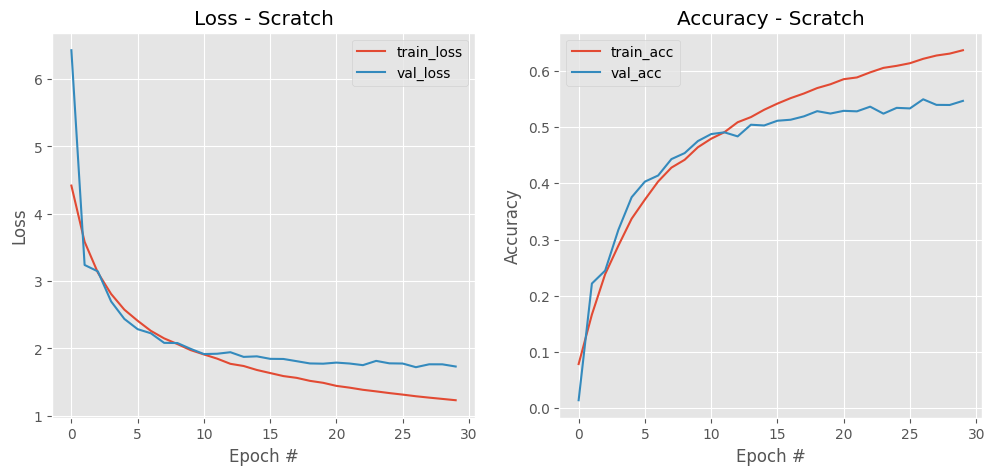

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam


# ============================================
# 1. Definición de la arquitectura CNN
# ============================================
model_scratch = Sequential([
    # Bloque 1
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Bloque 2
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Bloque 3
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Top Model (Clasificador)
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(100, activation='softmax')
])

model_scratch.summary()

# ============================================
# 2. Preprocesamiento (Normalización [0,1])
# ============================================
# Normalizamos los datos originales (0-255) a floats (0.0-1.0)
x_train_scratch = x_train.astype('float32') / 255.0
x_test_scratch = x_test.astype('float32') / 255.0

# ============================================
# 3. Entrenamiento
# ============================================
print("[INFO]: Compilando el modelo desde cero...")
model_scratch.compile(loss="categorical_crossentropy",
                      optimizer=Adam(learning_rate=0.001),
                      metrics=["accuracy"])

print("[INFO]: Entrenando el modelo...")
# Aumentamos un poco las épocas ya que al entrenar desde cero requiere más tiempo para converger
H_scratch = model_scratch.fit(x_train_scratch, y_train_cat,
                              batch_size=128,
                              epochs=30,
                              validation_split=0.2)

# ============================================
# 4. Evaluación y Gráficas
# ============================================
print("[INFO]: Evaluando el modelo...")
loss, accuracy = model_scratch.evaluate(x_test_scratch, y_test_cat, batch_size=128)
print(f"Accuracy en Test: {accuracy*100:.2f}%")

plt.style.use("ggplot")
plt.figure(figsize=(12, 5))

# Gráfica de Loss
plt.subplot(1, 2, 1)
plt.plot(np.arange(0, 30), H_scratch.history["loss"], label="train_loss")
plt.plot(np.arange(0, 30), H_scratch.history["val_loss"], label="val_loss")
plt.title("Loss - Scratch")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend()

# Gráfica de Accuracy
plt.subplot(1, 2, 2)
plt.plot(np.arange(0, 30), H_scratch.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 30), H_scratch.history["val_accuracy"], label="val_acc")
plt.title("Accuracy - Scratch")
plt.xlabel("Epoch #")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

### Bloques clásicos (Similar arquitectura al modelo anterior) (sin mejoría)

*Aunque el título original sugería una eliminación de la reducción de dimensionalidad, la arquitectura implementada es idéntica a la anterior, manteniendo las capas de MaxPooling. Por lo tanto, no se observaron mejoras significativas en el rendimiento. Se mantiene esta sección para ilustrar la continuidad del diseño inicial.*

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,391,236 (5.31 MB)

 Trainable params: 1,389,316 (5.30 MB)

 Non-trainable params: 1,920 (7.50 KB)

[INFO]: Compilando el modelo desde cero...
[INFO]: Entrenando el modelo...
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 47ms/step - accuracy: 0.1099 - loss: 4.1817 - val_accuracy: 0.0394 - val_loss: 5.1455
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.2266 - loss: 3.2303 - val_accuracy: 0.2684 - val_loss: 2.9624
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.3084 - loss: 2.7371 - val_accuracy: 0.3288 - val_loss: 2.6805
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.3702 - loss: 2.4265 - val_accuracy: 0.3963 - val_loss: 2.3639
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4083 - loss: 2.2347 - val_accuracy: 0.4200 - val_loss: 2.2263
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4442 - loss: 2.0783 - val_accuracy: 0.4354 - val_loss: 2.1812
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4715 - loss: 1.9396 - val_accuracy: 0.4654 - val_loss: 2.0368
Epoch 8/30
313/313 ━━

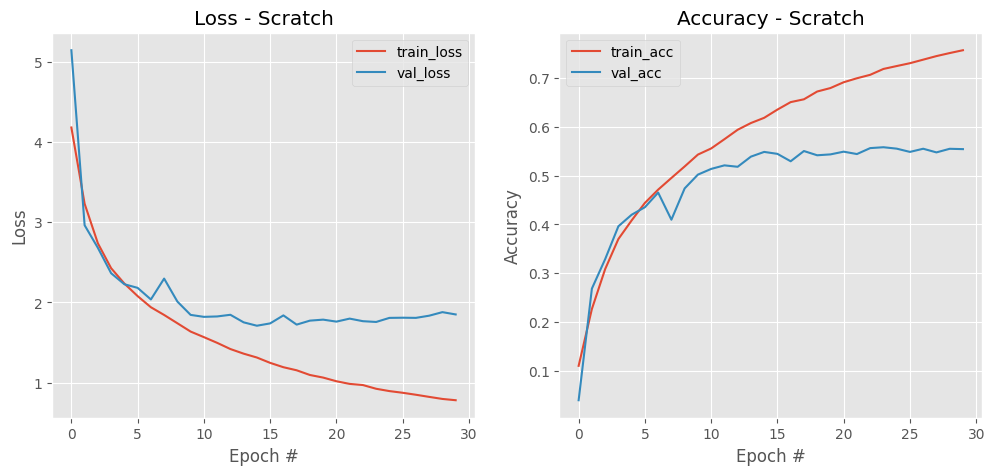

In [ ]:
# ============================================
# 1. Definición de la arquitectura CNN
# ============================================
model_scratch = Sequential([
    # Bloque 1
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Bloque 2
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Bloque 3
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Top Model (Clasificador)
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(100, activation='softmax')
])

model_scratch.summary()

# ============================================
# 2. Preprocesamiento (Normalización [0,1])
# ============================================
# Normalizamos los datos originales (0-255) a floats (0.0-1.0)
x_train_scratch = x_train.astype('float32') / 255.0
x_test_scratch = x_test.astype('float32') / 255.0

# ============================================
# 3. Entrenamiento
# ============================================
print("[INFO]: Compilando el modelo desde cero...")
model_scratch.compile(loss="categorical_crossentropy",
                      optimizer=Adam(learning_rate=0.001),
                      metrics=["accuracy"])

print("[INFO]: Entrenando el modelo...")
# Aumentamos un poco las épocas ya que al entrenar desde cero requiere más tiempo para converger
H_scratch = model_scratch.fit(x_train_scratch, y_train_cat,
                              batch_size=128,
                              epochs=30,
                              validation_split=0.2)

# ============================================
# 4. Evaluación y Gráficas
# ============================================
print("[INFO]: Evaluando el modelo...")
loss, accuracy = model_scratch.evaluate(x_test_scratch, y_test_cat, batch_size=128)
print(f"Accuracy en Test: {accuracy*100:.2f}%")

plt.style.use("ggplot")
plt.figure(figsize=(12, 5))

# Gráfica de Loss
plt.subplot(1, 2, 1)
plt.plot(np.arange(0, 30), H_scratch.history["loss"], label="train_loss")
plt.plot(np.arange(0, 30), H_scratch.history["val_loss"], label="val_loss")
plt.title("Loss - Scratch")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend()

# Gráfica de Accuracy
plt.subplot(1, 2, 2)
plt.plot(np.arange(0, 30), H_scratch.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 30), H_scratch.history["val_accuracy"], label="val_acc")
plt.title("Accuracy - Scratch")
plt.xlabel("Epoch #")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

### Sustitución de Flatten+Dense por GlobalAveragePooling2D (con mejoría)

*La sustitución de las capas `Flatten` y `Dense(512)` por `GlobalAveragePooling2D` en el Top Model es una técnica crucial para reducir drásticamente el número de parámetros y mitigar el sobreajuste. Esta modificación busca mejorar la capacidad de generalización del modelo, resultando en una ligera mejoría al reducir el overfitting.*

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             

 Total params: 302,212 (1.15 MB)

 Trainable params: 301,060 (1.15 MB)

 Non-trainable params: 1,152 (4.50 KB)

[INFO]: Compilando el modelo desde cero...
[INFO]: Entrenando el modelo...
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 41ms/step - accuracy: 0.0777 - loss: 4.2231 - val_accuracy: 0.0213 - val_loss: 5.3635
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.1706 - loss: 3.4556 - val_accuracy: 0.2072 - val_loss: 3.2664
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.2465 - loss: 3.0306 - val_accuracy: 0.2995 - val_loss: 2.7857
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.2950 - loss: 2.7787 - val_accuracy: 0.3425 - val_loss: 2.5655
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.3366 - loss: 2.5757 - val_accuracy: 0.3759 - val_loss: 2.3927
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.3609 - loss: 2.4449 - val_accuracy: 0.4007 - val_loss: 2.2810
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.3823 - loss: 2.3284 - val_accuracy: 0.4046 - val_loss: 2.2571
Epoch 8/30
313/313 ━━

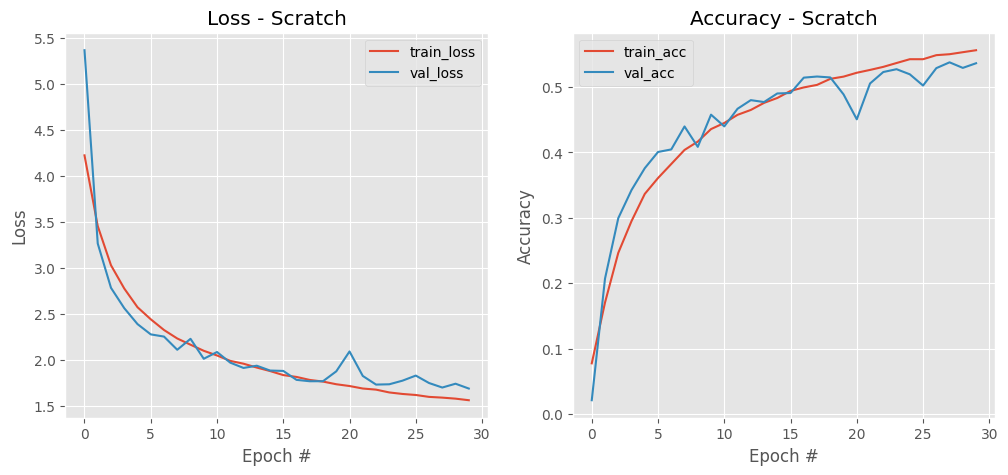

In [ ]:
# ============================================
# 1. Definición de la arquitectura CNN
# ============================================
model_scratch = Sequential([
    # Bloque 1
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Bloque 2
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Bloque 3
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Top Model (Clasificador)
    # Flatten(),
    # Dense(512, activation='relu'),
    layers.GlobalAveragePooling2D(),
    BatchNormalization(),
    Dropout(0.5),
    Dense(100, activation='softmax')
])

model_scratch.summary()

# ============================================
# 2. Preprocesamiento (Normalización [0,1])
# ============================================
# Normalizamos los datos originales (0-255) a floats (0.0-1.0)
x_train_scratch = x_train.astype('float32') / 255.0
x_test_scratch = x_test.astype('float32') / 255.0

# ============================================
# 3. Entrenamiento
# ============================================
print("[INFO]: Compilando el modelo desde cero...")
model_scratch.compile(loss="categorical_crossentropy",
                      optimizer=Adam(learning_rate=0.001),
                      metrics=["accuracy"])

print("[INFO]: Entrenando el modelo...")
# Aumentamos un poco las épocas ya que al entrenar desde cero requiere más tiempo para converger
H_scratch = model_scratch.fit(x_train_scratch, y_train_cat,
                              batch_size=128,
                              epochs=30,
                              validation_split=0.2)

# ============================================
# 4. Evaluación y Gráficas
# ============================================
print("[INFO]: Evaluando el modelo...")
loss, accuracy = model_scratch.evaluate(x_test_scratch, y_test_cat, batch_size=128)
print(f"Accuracy en Test: {accuracy*100:.2f}%")

plt.style.use("ggplot")
plt.figure(figsize=(12, 5))

# Gráfica de Loss
plt.subplot(1, 2, 1)
plt.plot(np.arange(0, 30), H_scratch.history["loss"], label="train_loss")
plt.plot(np.arange(0, 30), H_scratch.history["val_loss"], label="val_loss")
plt.title("Loss - Scratch")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend()

# Gráfica de Accuracy
plt.subplot(1, 2, 2)
plt.plot(np.arange(0, 30), H_scratch.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 30), H_scratch.history["val_accuracy"], label="val_acc")
plt.title("Accuracy - Scratch")
plt.xlabel("Epoch #")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

### Eliminación de un MaxPooling, adición de capa convolucional y Data Augmentation (búsqueda de mejora)

*Se realizan múltiples cambios en esta iteración con el objetivo de optimizar la extracción de características y la robustez del modelo. Se eliminó una capa `MaxPooling` para preservar más información espacial, se añadió una capa convolucional adicional para aumentar la complejidad de las características aprendidas y se incorporó Data Augmentation nativo para mejorar la capacidad de generalización. El impacto combinado de estas modificaciones busca una mejora en el rendimiento general del modelo.*

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,201,796 (4.58 MB)

 Trainable params: 1,199,876 (4.58 MB)

 Non-trainable params: 1,920 (7.50 KB)

[INFO]: Compilando el modelo desde cero...
[INFO]: Entrenando el modelo...
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.1382 - loss: 3.6742 - val_accuracy: 0.0252 - val_loss: 8.6746
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.2278 - loss: 3.1198 - val_accuracy: 0.2523 - val_loss: 3.0570
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.2817 - loss: 2.8404 - val_accuracy: 0.2566 - val_loss: 3.1490
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.3264 - loss: 2.6177 - val_accuracy: 0.3110 - val_loss: 2.7913
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.3618 - loss: 2.4605 - val_accuracy: 0.3627 - val_loss: 2.5085
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.3887 - loss: 2.3325 - val_accuracy: 0.3117 - val_loss: 2.9955
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.4146 - loss: 2.2087 - val_accuracy: 0.3877 - val_loss: 2.4147
Epoch 8/30
313/

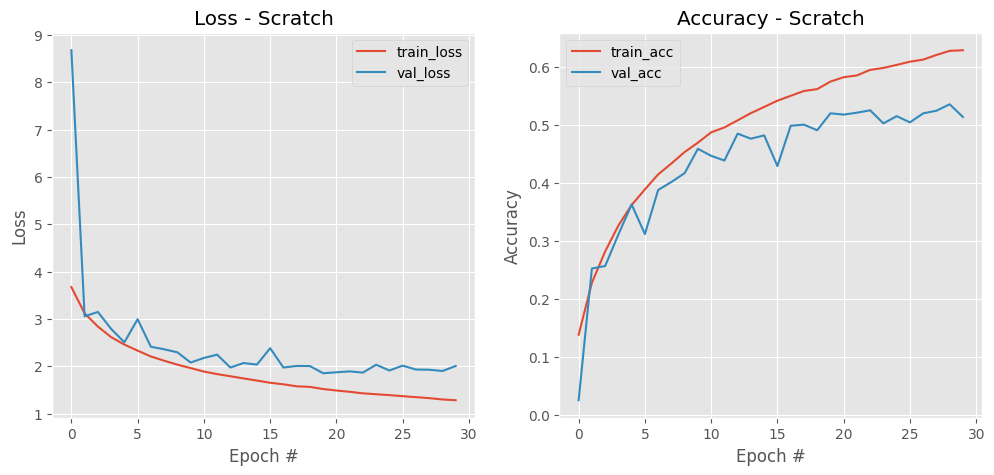

In [ ]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom


# ============================================
# 1. Definición de la arquitectura CNN
# ============================================
model_scratch = Sequential([
    Input(shape=(32, 32, 3)),

    # --- DATA AUGMENTATION NATIVO (Estrategia moderna) ---
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),

    # --- Bloque 1 ---
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)), # Baja a 16x16
    Dropout(0.2), # Dropout más suave

    # --- Bloque 2 ---
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)), # Baja a 8x8
    Dropout(0.3),

    # --- Bloque 3 ---
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    # ¡QUITAMOS EL MAX POOLING AQUÍ! (Tu idea)
    Dropout(0.4),

    # --- Bloque 4 ---
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    # Mantenemos 8x8 espacialmente, pero con 256 características de profundidad
    Dropout(0.4),

    # --- Top Model Moderno ---
    GlobalAveragePooling2D(), # Hace la media de cada uno de los 256 mapas de 8x8
    # Nos saltamos la capa Dense intermedia para evitar overfitting
    Dense(100, activation='softmax')
])

model_scratch.summary()

# ============================================
# 2. Preprocesamiento (Normalización [0,1])
# ============================================
# Normalizamos los datos originales (0-255) a floats (0.0-1.0)
x_train_scratch = x_train.astype('float32') / 255.0
x_test_scratch = x_test.astype('float32') / 255.0

# ============================================
# 3. Entrenamiento
# ============================================
print("[INFO]: Compilando el modelo desde cero...")
model_scratch.compile(loss="categorical_crossentropy",
                      optimizer=Adam(learning_rate=0.001),
                      metrics=["accuracy"])

print("[INFO]: Entrenando el modelo...")
# Aumentamos un poco las épocas ya que al entrenar desde cero requiere más tiempo para converger
H_scratch = model_scratch.fit(x_train_scratch, y_train_cat,
                              batch_size=128,
                              epochs=30,
                              validation_split=0.2)

# ============================================
# 4. Evaluación y Gráficas
# ============================================
print("[INFO]: Evaluando el modelo...")
loss, accuracy = model_scratch.evaluate(x_test_scratch, y_test_cat, batch_size=128)
print(f"Accuracy en Test: {accuracy*100:.2f}%")

plt.style.use("ggplot")
plt.figure(figsize=(12, 5))

# Gráfica de Loss
plt.subplot(1, 2, 1)
plt.plot(np.arange(0, 30), H_scratch.history["loss"], label="train_loss")
plt.plot(np.arange(0, 30), H_scratch.history["val_loss"], label="val_loss")
plt.title("Loss - Scratch")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend()

# Gráfica de Accuracy
plt.subplot(1, 2, 2)
plt.plot(np.arange(0, 30), H_scratch.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 30), H_scratch.history["val_accuracy"], label="val_acc")
plt.title("Accuracy - Scratch")
plt.xlabel("Epoch #")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

### Aumento de épocas para combatir el Sub-entrenamiento (intento de mejora)

*Se incrementa el número de épocas de entrenamiento con la finalidad de permitir que el modelo aprenda patrones más complejos y converja de manera más efectiva. Este ajuste busca mitigar el underfitting, esperando una mejora en la precisión tanto en entrenamiento como en validación.*

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_5 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_5               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_5 (RandomZoom)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_66          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_67          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_68          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_69          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_66 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,201,796 (4.58 MB)

 Trainable params: 1,199,876 (4.58 MB)

 Non-trainable params: 1,920 (7.50 KB)

[INFO]: Compilando el modelo desde cero...
[INFO]: Entrenando el modelo...
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.1338 - loss: 3.6952 - val_accuracy: 0.0304 - val_loss: 7.5136
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.2313 - loss: 3.1158 - val_accuracy: 0.2520 - val_loss: 3.0763
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.2889 - loss: 2.8041 - val_accuracy: 0.2665 - val_loss: 3.0914
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.3329 - loss: 2.5940 - val_accuracy: 0.2929 - val_loss: 2.9282
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.3642 - loss: 2.4398 - val_accuracy: 0.3365 - val_loss: 2.6313
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.3927 - loss: 2.3089 - val_accuracy: 0.3271 - val_loss: 2.8398
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.4147 - loss: 2.1993 - val_accuracy: 0.3860 - val_loss: 2.4878
Epoch 8/50
313/

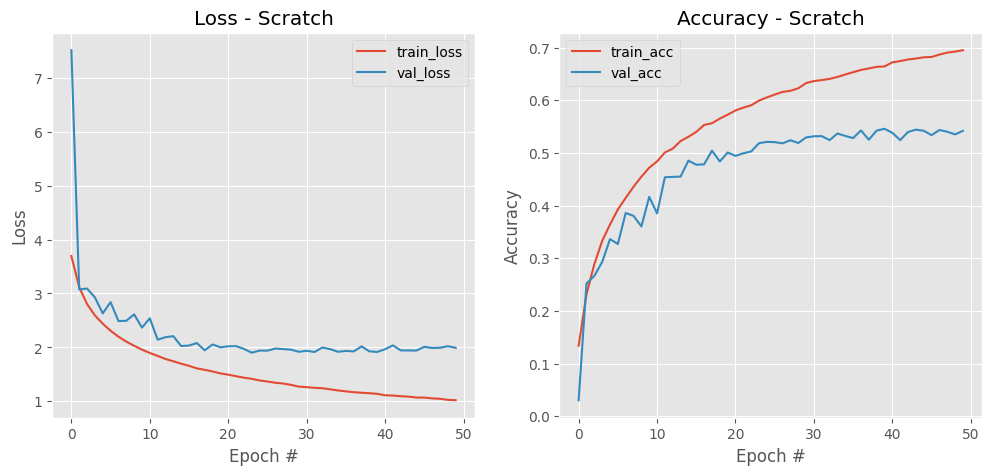

In [ ]:
# ============================================
# 1. Definición de la arquitectura CNN
# ============================================
model_scratch = Sequential([
    Input(shape=(32, 32, 3)),

    # --- DATA AUGMENTATION NATIVO (Estrategia moderna) ---
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),

    # --- Bloque 1 ---
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)), # Baja a 16x16
    Dropout(0.2), # Dropout más suave

    # --- Bloque 2 ---
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)), # Baja a 8x8
    Dropout(0.3),

    # --- Bloque 3 ---
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    # ¡QUITAMOS EL MAX POOLING AQUÍ! (Tu idea)
    Dropout(0.4),

    # --- Bloque 4 ---
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    # Mantenemos 8x8 espacialmente, pero con 256 características de profundidad
    Dropout(0.4),

    # --- Top Model Moderno ---
    GlobalAveragePooling2D(), # Hace la media de cada uno de los 256 mapas de 8x8
    # Nos saltamos la capa Dense intermedia para evitar overfitting
    Dense(100, activation='softmax')
])

model_scratch.summary()

# ============================================
# 2. Preprocesamiento (Normalización [0,1])
# ============================================
# Normalizamos los datos originales (0-255) a floats (0.0-1.0)
x_train_scratch = x_train.astype('float32') / 255.0
x_test_scratch = x_test.astype('float32') / 255.0

# ============================================
# 3. Entrenamiento
# ============================================
print("[INFO]: Compilando el modelo desde cero...")
model_scratch.compile(loss="categorical_crossentropy",
                      optimizer=Adam(learning_rate=0.001),
                      metrics=["accuracy"])

print("[INFO]: Entrenando el modelo...")
# Aumentamos un poco las épocas ya que al entrenar desde cero requiere más tiempo para converger
H_scratch = model_scratch.fit(x_train_scratch, y_train_cat,
                              batch_size=128,
                              epochs=50,
                              validation_split=0.2)

# ============================================
# 4. Evaluación y Gráficas
# ============================================
print("[INFO]: Evaluando el modelo...")
loss, accuracy = model_scratch.evaluate(x_test_scratch, y_test_cat, batch_size=128)
print(f"Accuracy en Test: {accuracy*100:.2f}%")

plt.style.use("ggplot")
plt.figure(figsize=(12, 5))

# Gráfica de Loss
plt.subplot(1, 2, 1)
plt.plot(np.arange(0, 50), H_scratch.history["loss"], label="train_loss")
plt.plot(np.arange(0, 50), H_scratch.history["val_loss"], label="val_loss")
plt.title("Loss - Scratch")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend()

# Gráfica de Accuracy
plt.subplot(1, 2, 2)
plt.plot(np.arange(0, 50), H_scratch.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 50), H_scratch.history["val_accuracy"], label="val_acc")
plt.title("Accuracy - Scratch")
plt.xlabel("Epoch #")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

### Eliminación de la capa convolucional adicional (búsqueda de optimización)

*En un esfuerzo por simplificar la arquitectura y potencialmente reducir el overfitting si la capa adicional contribuía a ello, se procede a eliminar la cuarta capa convolucional introducida anteriormente. Esta modificación busca un equilibrio entre la complejidad del modelo y su capacidad de generalización.*

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_4 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_4               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_4 (RandomZoom)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_62          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_63          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 301,700 (1.15 MB)

 Trainable params: 300,804 (1.15 MB)

 Non-trainable params: 896 (3.50 KB)

[INFO]: Compilando el modelo desde cero...
[INFO]: Entrenando el modelo...
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.1276 - loss: 3.7654 - val_accuracy: 0.0161 - val_loss: 7.1284
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.2162 - loss: 3.2328 - val_accuracy: 0.2118 - val_loss: 3.2715
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.2720 - loss: 2.9188 - val_accuracy: 0.2484 - val_loss: 3.0943
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.3078 - loss: 2.7090 - val_accuracy: 0.2666 - val_loss: 3.0571
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.3421 - loss: 2.5544 - val_accuracy: 0.3334 - val_loss: 2.6363
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.3653 - loss: 2.4379 - val_accuracy: 0.3071 - val_loss: 2.8007
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.3859 - loss: 2.3516 - val_accuracy: 0.3416 - val_loss: 2.6183
Epoch 8/50
313/

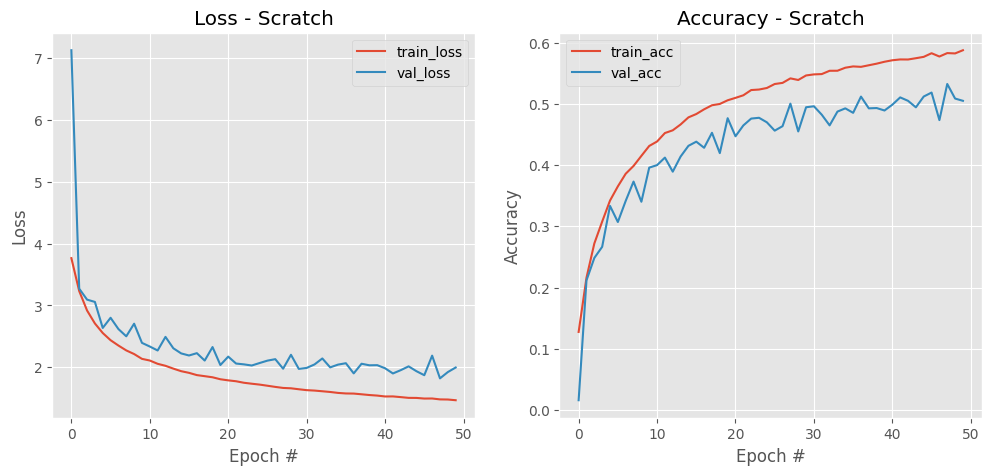

In [ ]:
# ============================================
# 1. Definición de la arquitectura CNN
# ============================================
model_scratch = Sequential([
    Input(shape=(32, 32, 3)),

    # 1. Data Augmentation Ligero
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),

    # 2. Bloque 1 (32 filtros)
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)), # Baja a 16x16
    Dropout(0.2),

    # 3. Bloque 2 (64 filtros)
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)), # Baja a 8x8
    Dropout(0.3),

    # 4. Bloque 3 (128 filtros) - El último bloque
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    # SIN MAX POOLING AQUÍ para mantener la riqueza espacial de 8x8
    Dropout(0.4),

    # 5. Top Model Directo
    GlobalAveragePooling2D(),
    Dense(100, activation='softmax')
])

model_scratch.summary()

# ============================================
# 2. Preprocesamiento (Normalización [0,1])
# ============================================
# Normalizamos los datos originales (0-255) a floats (0.0-1.0)
x_train_scratch = x_train.astype('float32') / 255.0
x_test_scratch = x_test.astype('float32') / 255.0

# ============================================
# 3. Entrenamiento
# ============================================
print("[INFO]: Compilando el modelo desde cero...")
model_scratch.compile(loss="categorical_crossentropy",
                      optimizer=Adam(learning_rate=0.001),
                      metrics=["accuracy"])

print("[INFO]: Entrenando el modelo...")
# Aumentamos un poco las épocas ya que al entrenar desde cero requiere más tiempo para converger
H_scratch = model_scratch.fit(x_train_scratch, y_train_cat,
                              batch_size=128,
                              epochs=50,
                              validation_split=0.2)

# ============================================
# 4. Evaluación y Gráficas
# ============================================
print("[INFO]: Evaluando el modelo...")
loss, accuracy = model_scratch.evaluate(x_test_scratch, y_test_cat, batch_size=128)
print(f"Accuracy en Test: {accuracy*100:.2f}%")

plt.style.use("ggplot")
plt.figure(figsize=(12, 5))

# Gráfica de Loss
plt.subplot(1, 2, 1)
plt.plot(np.arange(0, 50), H_scratch.history["loss"], label="train_loss")
plt.plot(np.arange(0, 50), H_scratch.history["val_loss"], label="val_loss")
plt.title("Loss - Scratch")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend()

# Gráfica de Accuracy
plt.subplot(1, 2, 2)
plt.plot(np.arange(0, 50), H_scratch.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 50), H_scratch.history["val_accuracy"], label="val_acc")
plt.title("Accuracy - Scratch")
plt.xlabel("Epoch #")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

### Optimización con LR variable, Data Augmentation mejorado y Regularización L2 (con mejoría)

*Se implementa un Learning Rate variable mediante `ReduceLROnPlateau` para suavizar el proceso de entrenamiento y permitir una convergencia más fina. Además, se ajusta el método de Data Augmentation a `RandomTranslation` por considerarse más adecuado para este tipo de datos y se añade regularización L2 en las capas convolucionales para controlar el sobreajuste. Estas técnicas combinadas buscan una mejora robusta en la estabilidad y precisión del modelo.*

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_6 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_6               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_68 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_72          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_73          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_74          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_75          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_76          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_77          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 4, 4, 256)      │             

 Total params: 1,174,692 (4.48 MB)

 Trainable params: 1,172,900 (4.47 MB)

 Non-trainable params: 1,792 (7.00 KB)

[INFO]: Compilando el modelo desde cero...
[INFO]: Entrenando el modelo...
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.1347 - loss: 3.8136 - val_accuracy: 0.0218 - val_loss: 7.5529 - learning_rate: 0.0010
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.2327 - loss: 3.2035 - val_accuracy: 0.2470 - val_loss: 3.1639 - learning_rate: 0.0010
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.3021 - loss: 2.8675 - val_accuracy: 0.2378 - val_loss: 3.3238 - learning_rate: 0.0010
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.3493 - loss: 2.6437 - val_accuracy: 0.2934 - val_loss: 3.0838 - learning_rate: 0.0010
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.3910 - loss: 2.4745 - val_accuracy: 0.2374 - val_loss: 3.5067 - learning_rate: 0.0010
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.4257 - loss: 2.3531 - val_accuracy: 0.4135 - val_loss: 2.4884 - learning_rate: 0.0010
E

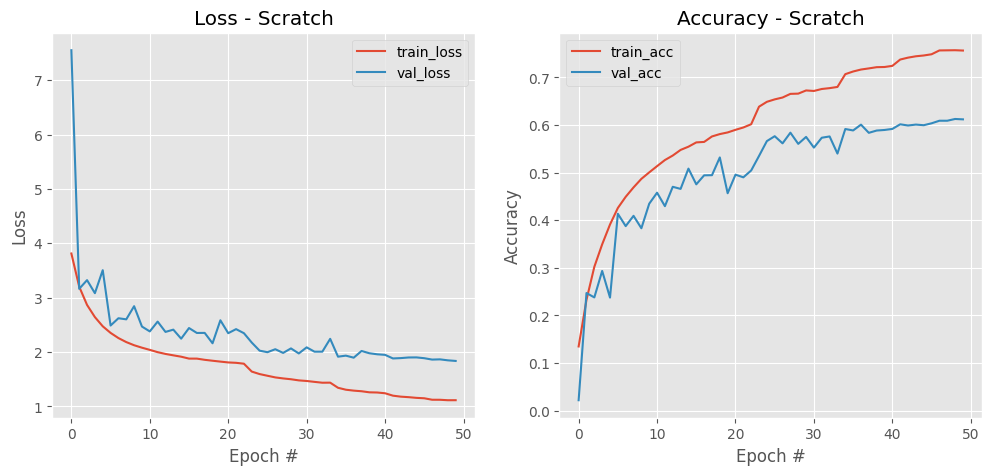

In [ ]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping


peso_l2 = 1e-4

# ============================================
# 1. Definición de la arquitectura CNN
# ============================================
model_scratch = Sequential([
    Input(shape=(32, 32, 3)),

    # --- Data Augmentation Clásico para CIFAR ---
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomTranslation(height_factor=0.1, width_factor=0.1), # Mejor que el Zoom

    # --- Bloque 1 ---
    Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(peso_l2)),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(peso_l2)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    # --- Bloque 2 ---
    Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(peso_l2)),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(peso_l2)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    # --- Bloque 3 ---
    Conv2D(256, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(peso_l2)),
    BatchNormalization(),
    Conv2D(256, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(peso_l2)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)), # Bajamos a 4x4, está bien con 256 filtros
    Dropout(0.4),

    # --- Top Model ---
    GlobalAveragePooling2D(),
    Dense(100, activation='softmax')
])

model_scratch.summary()

# ============================================
# 2. Preprocesamiento (Normalización [0,1])
# ============================================
# Normalizamos los datos originales (0-255) a floats (0.0-1.0)
x_train_scratch = x_train.astype('float32') / 255.0
x_test_scratch = x_test.astype('float32') / 255.0

# ============================================
# 3. Entrenamiento
# ============================================
print("[INFO]: Compilando el modelo desde cero...")
model_scratch.compile(loss="categorical_crossentropy",
                      optimizer=Adam(learning_rate=0.001),
                      metrics=["accuracy"])

# 2. DEFINIMOS LOS CALLBACKS
# Si en 4 épocas no mejora el val_loss, reduce el LR a la mitad.
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5, verbose=1)

# Si en 12 épocas no mejora nada, para el entrenamiento para no perder tiempo
early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)

print("[INFO]: Entrenando el modelo...")
# Aumentamos un poco las épocas ya que al entrenar desde cero requiere más tiempo para converger
H_scratch = model_scratch.fit(x_train_scratch, y_train_cat,
                              batch_size=128,
                              epochs=50,
                              validation_split=0.2,
                              callbacks=[lr_scheduler, early_stop])

# ============================================
# 4. Evaluación y Gráficas
# ============================================
print("[INFO]: Evaluando el modelo...")
loss, accuracy = model_scratch.evaluate(x_test_scratch, y_test_cat, batch_size=128)
print(f"Accuracy en Test: {accuracy*100:.2f}%")

plt.style.use("ggplot")
plt.figure(figsize=(12, 5))

# Gráfica de Loss
plt.subplot(1, 2, 1)
plt.plot(np.arange(0, 50), H_scratch.history["loss"], label="train_loss")
plt.plot(np.arange(0, 50), H_scratch.history["val_loss"], label="val_loss")
plt.title("Loss - Scratch")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend()

# Gráfica de Accuracy
plt.subplot(1, 2, 2)
plt.plot(np.arange(0, 50), H_scratch.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 50), H_scratch.history["val_accuracy"], label="val_acc")
plt.title("Accuracy - Scratch")
plt.xlabel("Epoch #")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

### Implementación de Label Smoothing y aumento de épocas (con mejoría)

*La introducción de `Label Smoothing` en la función de pérdida (`CategoricalCrossentropy`) busca suavizar las etiquetas objetivo, haciendo que el modelo sea menos sensible a las etiquetas incorrectas y mejorando su robustez. Junto con un aumento en el número de épocas, se pretende consolidar las mejoras previas y lograr una mayor precisión y una mejor generalización.*

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_7 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_7               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_1            │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_74 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_78          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_79          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_80          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_81          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_82          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_83          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 4, 4, 256)      │             

 Total params: 1,174,692 (4.48 MB)

 Trainable params: 1,172,900 (4.47 MB)

 Non-trainable params: 1,792 (7.00 KB)

[INFO]: Compilando el modelo desde cero...
[INFO]: Entrenando el modelo...
Epoch 1/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 57ms/step - accuracy: 0.1354 - loss: 3.9926 - val_accuracy: 0.0176 - val_loss: 6.2878 - learning_rate: 0.0010
Epoch 2/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.2368 - loss: 3.4981 - val_accuracy: 0.2499 - val_loss: 3.4982 - learning_rate: 0.0010
Epoch 3/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.3013 - loss: 3.2454 - val_accuracy: 0.2504 - val_loss: 3.6019 - learning_rate: 0.0010
Epoch 4/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.3530 - loss: 3.0586 - val_accuracy: 0.2898 - val_loss: 3.4392 - learning_rate: 0.0010
Epoch 5/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.3949 - loss: 2.9333 - val_accuracy: 0.3912 - val_loss: 3.0146 - learning_rate: 0.0010
Epoch 6/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.4259 - loss: 2.8390 - val_accuracy: 0.3324 - val_loss: 3.3129 - learning_rate: 0.0010
E

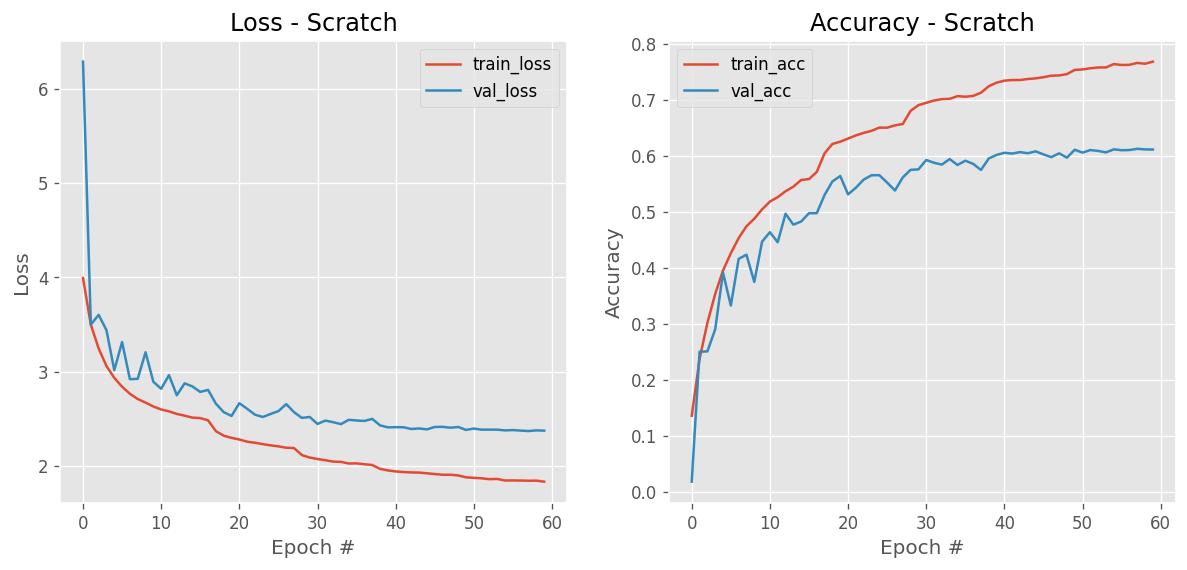

In [ ]:
from tensorflow.keras.losses import CategoricalCrossentropy


peso_l2 = 1e-4

# ============================================
# 1. Definición de la arquitectura CNN
# ============================================
model_scratch = Sequential([
    Input(shape=(32, 32, 3)),

    # --- Data Augmentation Clásico para CIFAR ---
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomTranslation(height_factor=0.1, width_factor=0.1), # Mejor que el Zoom

    # --- Bloque 1 ---
    Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(peso_l2)),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(peso_l2)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    # --- Bloque 2 ---
    Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(peso_l2)),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(peso_l2)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    # --- Bloque 3 ---
    Conv2D(256, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(peso_l2)),
    BatchNormalization(),
    Conv2D(256, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(peso_l2)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)), # Bajamos a 4x4, está bien con 256 filtros
    Dropout(0.4),

    # --- Top Model ---
    GlobalAveragePooling2D(),
    Dense(100, activation='softmax')
])

model_scratch.summary()

# ============================================
# 2. Preprocesamiento (Normalización [0,1])
# ============================================
# Normalizamos los datos originales (0-255) a floats (0.0-1.0)
x_train_scratch = x_train.astype('float32') / 255.0
x_test_scratch = x_test.astype('float32') / 255.0

# ============================================
# 3. Entrenamiento
# ============================================
print("[INFO]: Compilando el modelo desde cero...")
model_scratch.compile(loss=CategoricalCrossentropy(label_smoothing=0.1), # Introducimos lable_smoothing aquí
                      optimizer=Adam(learning_rate=0.001),
                      metrics=["accuracy"])

# 2. DEFINIMOS LOS CALLBACKS
# Si en 4 épocas no mejora el val_loss, reduce el LR a la mitad.
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5, verbose=1)

# Si en 12 épocas no mejora nada, para el entrenamiento para no perder tiempo
early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)

print("[INFO]: Entrenando el modelo...")
# Aumentamos un poco las épocas ya que al entrenar desde cero requiere más tiempo para converger
H_scratch = model_scratch.fit(x_train_scratch, y_train_cat,
                              batch_size=128,
                              epochs=60,
                              validation_split=0.2,
                              callbacks=[lr_scheduler, early_stop])

# ============================================
# 4. Evaluación y Gráficas
# ============================================
print("[INFO]: Evaluando el modelo...")
loss, accuracy = model_scratch.evaluate(x_test_scratch, y_test_cat, batch_size=128)
print(f"Accuracy en Test: {accuracy*100:.2f}%")

plt.style.use("ggplot")
plt.figure(figsize=(12, 5))

# Gráfica de Loss
plt.subplot(1, 2, 1)
plt.plot(np.arange(0, 60), H_scratch.history["loss"], label="train_loss")
plt.plot(np.arange(0, 60), H_scratch.history["val_loss"], label="val_loss")
plt.title("Loss - Scratch")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend()

# Gráfica de Accuracy
plt.subplot(1, 2, 2)
plt.plot(np.arange(0, 60), H_scratch.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 60), H_scratch.history["val_accuracy"], label="val_acc")
plt.title("Accuracy - Scratch")
plt.xlabel("Epoch #")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## **Conclusiones Finales**

Tras el diseño, entrenamiento y evaluación de las dos estrategias propuestas para la clasificación del dataset CIFAR-100, hemos extraído conclusiones fundamentales sobre el comportamiento de las Redes Neuronales Convolucionales (CNN) y la escalabilidad de las arquitecturas.

### **1. El reto de entrenar "Desde Cero" (Estrategia 2)**
Diseñar un modelo secuencial (*From Scratch*) para un problema complejo (100 clases, baja resolución de 32x32) ha demostrado ser un ejercicio constante de equilibrio entre el sesgo y la varianza. Durante nuestra experimentación empírica, observamos que:
* **El Peligro del Sobreajuste:** Los modelos iniciales con capas `Flatten` y redes densas masivas memorizaban el conjunto de entrenamiento rápidamente, fracasando en la validación.
* **Técnicas de Regularización:** Fue estrictamente necesario sustituir `Flatten` por `GlobalAveragePooling2D` para reducir drásticamente los parámetros. Además, el uso combinado de **Data Augmentation** (traslaciones, rotaciones y volteos), **Dropout**, regularización de pesos (**L2**) y **Label Smoothing** fue crítico para entrenar correctamente a la red y forzarla a generalizar.
* **El límite arquitectónico:** A pesar de optimizar el entrenamiento con *Callbacks* (`ReduceLROnPlateau` y `EarlyStopping`), el modelo alcanzó un techo de cristal en torno al **61-62% de precisión**. Hemos comprobado que apilar bloques convolucionales linealmente (API Sequential) sufre de pérdida de información espacial.

### **2. La superioridad del Transfer Learning (Estrategia 1)**
En contraste con el laborioso proceso de la Estrategia 2, la utilización de modelos pre-entrenados en ImageNet demostró el inmenso valor de la transferencia de conocimiento:
* Arquitecturas avanzadas como **EfficientNet** son capaces de extraer características de altísima complejidad desde la primera época gracias a sus pesos previamente calculados.
* Hemos comprobado que el éxito del *Fine-Tuning* radica en el rigor metodológico: es imperativo realizar un "warm-up" de la nueva capa final manteniendo el modelo base congelado, para evitar que los gradientes aleatorios destruyan el conocimiento previo.
* Solo tras estabilizar el *Top Model*, la descongelación selectiva de las últimas capas convolucionales con un *Learning Rate* pequeño permite adaptar la red a las particularidades de CIFAR-100.

### **Conclusión General**
La experimentación ha demostrado que, aunque diseñar una red desde cero aporta un conocimiento sobre la topología y regularización de los datos, para problemas complejos en el estado del arte actual es casi imposible igualar el rendimiento y eficiencia del **Transfer Learning**. No por añadir más capas o neuronas a un modelo secuencial se obtienen mejores resultados; el avance real reside en arquitecturas innovadoras y en el aprovechamiento del conocimiento visual previamente aprendido por modelos más grandes.